In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

import logomaker

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [2]:
library = pd.read_csv('../../source_data/02_library/CDK_library_final.csv')


#-----load single amino-acid variants (SAVs) breakdown for each subpool------
SAV_ABE1 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool1.zip')
SAV_ABE1 = pd.merge(SAV_ABE1, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE1 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool1.zip')
SAV_CBE1 = pd.merge(SAV_CBE1, library[['gRNA_id', 'Gene']], on='gRNA_id')


SAV_ABE2 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool2.zip')
SAV_ABE2 = pd.merge(SAV_ABE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE2 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool2.zip')
SAV_CBE2 = pd.merge(SAV_CBE2, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_ABE3 = pd.read_csv('../../screening_data/04_editing/SAVs/ABE_subpool3.zip')
SAV_ABE3 = pd.merge(SAV_ABE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

SAV_CBE3 = pd.read_csv('../../screening_data/04_editing/SAVs/CBE_subpool3.zip')
SAV_CBE3 = pd.merge(SAV_CBE3, library[['gRNA_id', 'Gene']], on='gRNA_id')

#------also load the raw editing for each (i.e. with compound mutations) -------

ABE1 = pd.read_csv('../../screening_data/04_editing/ABE_subpool1_HGVSp.zip')
CBE1 = pd.read_csv('../../screening_data/04_editing/CBE_subpool1_HGVSp.zip')
ABE2 = pd.read_csv('../../screening_data/04_editing/ABE_CDK12_13_HGVSp.zip')
CBE2 = pd.read_csv('../../screening_data/04_editing/CBE_CDK12_13_HGVSp.zip')
ABE3 = pd.read_csv('../../screening_data/04_editing/ABE_CDK2_4_6_HGVSp.zip')
CBE3 = pd.read_csv('../../screening_data/04_editing/CBE_CDK2_4_6_HGVSp.zip')

In [590]:
CBE1[CBE1['gRNA_id']=='gRNA_CDK9_targ_1475']

,gRNA_id,HGVSp,#Reads,%Reads
686655,gRNA_CDK9_targ_1475,C106Y_E107K,44048,62.091909
686656,gRNA_CDK9_targ_1475,D104N_C106Y_E107K,5301,7.472512
686657,gRNA_CDK9_targ_1475,C106Y,3995,5.631520
686658,gRNA_CDK9_targ_1475,D104N_C106Y,3864,5.446856
686659,gRNA_CDK9_targ_1475,C106Y_E107Q,1534,2.162391
...,...,...,...,...
686957,gRNA_CDK9_targ_1475,V102S_F103T_D104Y_F105T_C106S,1,0.001410
686958,gRNA_CDK9_targ_1475,V102T_F103W_D104C_F105S,1,0.001410
686959,gRNA_CDK9_targ_1475,V102Y_F103I_C106Y,1,0.001410
686960,gRNA_CDK9_targ_1475,V102Y_F103I_C106Y_H108D,1,0.001410


In [48]:
np.unique(SAV_ABE1['gRNA_id'])

array(['gRNA_CDK19_targ_6273', 'gRNA_CDK19_targ_6274',
       'gRNA_CDK19_targ_6275', ..., 'gRNA_CDK9_targ_1737',
       'gRNA_CDK9_targ_1738', 'gRNA_CDK9_targ_1739'], dtype=object)

In [3]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]



def logo_df_maker(merge, gRNA_id, context_size, min_perc):

    gene = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]

    cdks = pd.read_csv('../../source_data/01_library_generation_files/cdks_info_updated.csv')

    cdk_prot = cdks.loc[cdks['Gene']==gene, 'Protein'].values[0]

    d4 = merge[(merge['HGVSp']!='WT') & (merge['%Reads']>=min_perc) & (merge['gRNA_id']==gRNA_id)]
    
    codons = []
    refs = []
    alts = []
    for i, val in d4.iterrows():
        h = val['HGVSp']
        c = val['%Reads']

        codon = extract_numbers(h)
        ref = h[0]
        alt = h[-1]
        codons.append(codon)
        refs.append(ref)
        alts.append(alt)

    d4['codon'] = codons
    d4['ref'] = refs
    d4['alt'] = alts

    min_cod = min(d4['codon'])
    max_cod = max(d4['codon'])

    assert cdk_prot[min_cod-1] == d4.loc[d4['codon']==min_cod, 'ref'].values[0]
    assert cdk_prot[max_cod-1] == d4.loc[d4['codon']==max_cod, 'ref'].values[0]

    start_cod = max(min_cod-context_size, 0)
    end_cod = min(max_cod +context_size, len(cdk_prot))

    codon_options = np.unique([i for i in cdk_prot[start_cod-1: end_cod]] + refs + alts)

    sequence = cdk_prot[start_cod-1: end_cod]
    seq_length = len(sequence)

    zero_array = [list(range(start_cod, end_cod+1))] + [np.zeros(seq_length) for i in range(len(codon_options))]

    logo_df = pd.DataFrame(dict(zip(['codon'] + list(codon_options), zero_array)))

    for i, val in d4.iterrows():
        cod = val['codon']
        alt = val['alt']
        perc = val['%Reads']

        logo_df.loc[logo_df['codon']==cod, alt]+=perc

    for i, val in enumerate(list(range(start_cod, end_cod+1))):
        cod = val
        aa = sequence[i]

        remaining_prob = 100 - np.sum(logo_df[logo_df['codon']==cod][codon_options].values)

        logo_df.loc[logo_df['codon']==cod, aa]+=remaining_prob

    logo_df = logo_df.set_index('codon')

    return logo_df, min_cod, max_cod, d4, sequence

In [58]:
gene = merge.loc[merge['gRNA_id']=='gRNA_id', 'Gene']
gene

Series([], Name: Gene, dtype: object)

In [463]:
def logo_plotter(gRNA_id, logo_df, ABE1, d4, min_perc):
    
    fig, ax = plt.subplots(figsize=(8,2))
    ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax)
    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=12)
    ss_logo.ax.set_yticks([0,25, 50, 75,100])
    ss_logo.ax.set_yticklabels([0,25, 50, 75,100], fontsize=12);
    ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['%Reads']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['%Reads']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

    ss_logo.style_spines(spines=['left', 'right', 'top'], visible=False)

    subset = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]

    s2 = ''
    for i, val in subset[:5].iterrows():
        pp = val['%Reads']
        s2 += f"{val['HGVSp']}, {np.round(pp,1)}%, "


    ss_logo.ax.set_title(f'{s2}', fontsize=14)

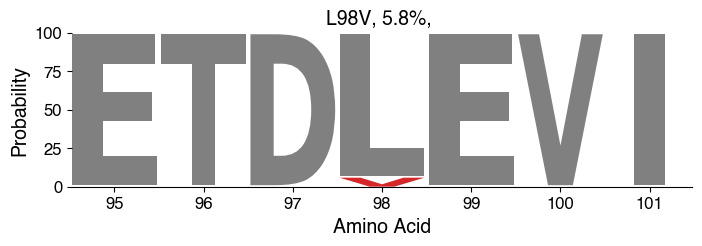

In [299]:
merge = SAV_CBE1
gRNA_id = 'gRNA_CDK7_targ_70'
context_size=3
min_perc = 2

logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

logo_plotter(gRNA_id, logo_df, CBE1, d4, min_perc=2)

In [300]:
CBE1[CBE1['gRNA_id']==gRNA_id]

,gRNA_id,HGVSp,#Reads,%Reads
330769,gRNA_CDK7_targ_70,WT,61005,91.452171
330770,gRNA_CDK7_targ_70,L98V,3879,5.814982
330771,gRNA_CDK7_targ_70,L98I,268,0.401757
330772,gRNA_CDK7_targ_70,M94V,175,0.262341
330773,gRNA_CDK7_targ_70,E99*,154,0.230860
...,...,...,...,...
330882,gRNA_CDK7_targ_70,T96N_E99Q,1,0.001499
330883,gRNA_CDK7_targ_70,T96N_L98I,1,0.001499
330884,gRNA_CDK7_targ_70,T96N_L98R,1,0.001499
330885,gRNA_CDK7_targ_70,T96N_L98R_E99G,1,0.001499


In [ ]:
min_edit = 60
a = list(np.unique(SAV_CBE1[(SAV_CBE1['Gene']=='CDK9') & (SAV_CBE1['HGVSp']!='WT') & (SAV_CBE1['%Reads']>=min_edit)]['Codon']))

In [323]:
d = []
for min_edit in range(1,100):

    a = list(np.unique(SAV_CBE1[(SAV_CBE1['Gene']=='CDK9') & (SAV_CBE1['HGVSp']!='WT') & (SAV_CBE1['%Reads']>=min_edit)]['Codon']))
    b = list(np.unique(SAV_ABE1[(SAV_ABE1['Gene']=='CDK9') & (SAV_ABE1['HGVSp']!='WT') & (SAV_ABE1['%Reads']>=min_edit)]['Codon']))

    c = len(np.unique(a+b))
    d.append(c/372)
    print(f'{min_edit} {c/372}')

1 1.0
2 0.9973118279569892
3 0.9946236559139785
4 0.9946236559139785
5 0.9946236559139785
6 0.9946236559139785
7 0.9946236559139785
8 0.9919354838709677
9 0.9919354838709677
10 0.9865591397849462
11 0.9865591397849462
12 0.9865591397849462
13 0.9838709677419355
14 0.9758064516129032
15 0.9704301075268817
16 0.9704301075268817
17 0.9704301075268817
18 0.9623655913978495
19 0.9596774193548387
20 0.956989247311828
21 0.9489247311827957
22 0.946236559139785
23 0.946236559139785
24 0.9408602150537635
25 0.9381720430107527
26 0.9354838709677419
27 0.9354838709677419
28 0.9274193548387096
29 0.9220430107526881
30 0.9139784946236559
31 0.9139784946236559
32 0.9086021505376344
33 0.9086021505376344
34 0.9059139784946236
35 0.9032258064516129
36 0.9005376344086021
37 0.8951612903225806
38 0.8951612903225806
39 0.8924731182795699
40 0.8870967741935484
41 0.8790322580645161
42 0.8736559139784946
43 0.8682795698924731
44 0.8548387096774194
45 0.8548387096774194
46 0.8467741935483871
47 0.8413978494

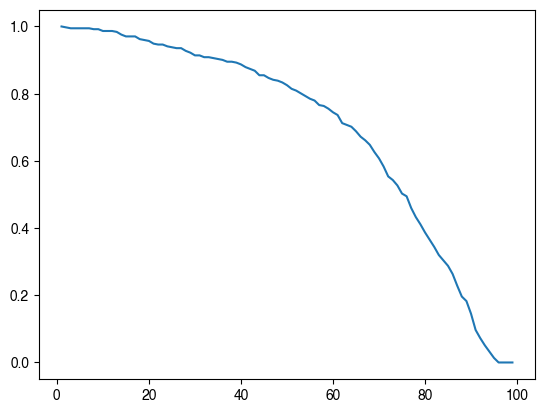

In [324]:
plt.plot(range(1,100), d)

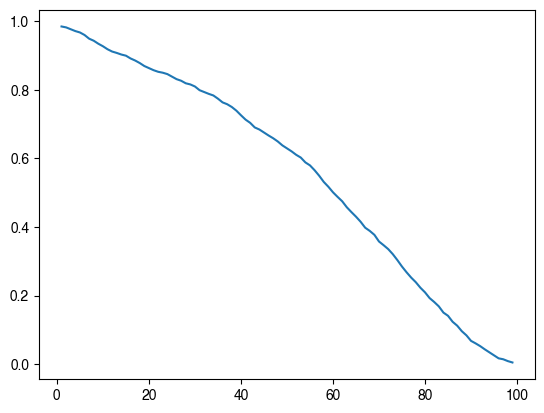

In [329]:
plt.plot(range(1,100), d)

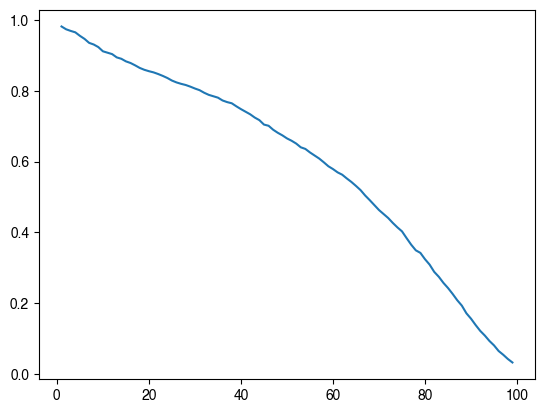

In [331]:
plt.plot(range(1,100), d)

In [330]:
d = []
g = 'CDK13'
for min_edit in range(1,100):

    a = list(np.unique(SAV_CBE2[(SAV_CBE2['Gene']==g) & (SAV_CBE2['HGVSp']!='WT') & (SAV_CBE2['%Reads']>=min_edit)]['Codon']))
    b = list(np.unique(SAV_ABE2[(SAV_ABE2['Gene']==g) & (SAV_ABE2['HGVSp']!='WT') & (SAV_ABE2['%Reads']>=min_edit)]['Codon']))

    c = len(np.unique(a+b))
    d.append(c/1512)
    print(f'{min_edit} {c/1512} {c}')

1 0.9814814814814815 1484
2 0.9735449735449735 1472
3 0.968915343915344 1465
4 0.96494708994709 1459
5 0.955026455026455 1444
6 0.9464285714285714 1431
7 0.9351851851851852 1414
8 0.9305555555555556 1407
9 0.9232804232804233 1396
10 0.9113756613756614 1378
11 0.9074074074074074 1372
12 0.9034391534391535 1366
13 0.8941798941798942 1352
14 0.8902116402116402 1346
15 0.8829365079365079 1335
16 0.8783068783068783 1328
17 0.8716931216931217 1318
18 0.8644179894179894 1307
19 0.8591269841269841 1299
20 0.8551587301587301 1293
21 0.8518518518518519 1288
22 0.8472222222222222 1281
23 0.841931216931217 1273
24 0.8359788359788359 1264
25 0.8287037037037037 1253
26 0.8234126984126984 1245
27 0.8194444444444444 1239
28 0.8161375661375662 1234
29 0.8115079365079365 1227
30 0.8062169312169312 1219
31 0.8015873015873016 1212
32 0.7943121693121693 1201
33 0.7883597883597884 1192
34 0.7843915343915344 1186
35 0.7804232804232805 1180
36 0.7724867724867724 1168
37 0.7678571428571429 1161
38 0.7645502645

In [301]:
#ISSUE HERE!!! -- NEED TO FIX!!! (COULD AFFECT MUTATION ANALYSIS AS WELL!!!)

SAV_CBE1[SAV_CBE1['gRNA_id']==gRNA_id]

,HGVSp,#Reads,%Reads,gRNA_id,Codon,Gene
84991,WT,61005,91.452171,gRNA_CDK7_targ_70,WT,CDK7
84992,L98V,3952,5.924416,gRNA_CDK7_targ_70,98,CDK7
84993,L98I,281,0.421245,gRNA_CDK7_targ_70,98,CDK7
84994,M94V,184,0.275833,gRNA_CDK7_targ_70,94,CDK7
84995,E99*,180,0.269837,gRNA_CDK7_targ_70,99,CDK7
84996,M94I,162,0.242853,gRNA_CDK7_targ_70,94,CDK7
84997,T96N,140,0.209873,gRNA_CDK7_targ_70,96,CDK7
84998,E95*,132,0.197880,gRNA_CDK7_targ_70,95,CDK7
84999,D97Y,131,0.196381,gRNA_CDK7_targ_70,97,CDK7
85000,D97E,60,0.089946,gRNA_CDK7_targ_70,97,CDK7


# ALSO MAKE A DNA VERSION

# Combined plots

In [335]:
data = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')

condition = 'HQ461'
FDR_cutoff = 0.1

all_conditions = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

if (f'LFC_median_ABE_{condition}' in data.columns) or (f'LFC_median_CBE_{condition}' in data.columns):
    try:
        subset = data[(data[f'FDR_ABE_{condition}']<FDR_cutoff)  & (data['classification']=='targeting')].sort_values(by=f'LFC_median_ABE_{condition}', ascending=False)
    except:
        subset = data[(data[f'FDR_CBE_{condition}']<FDR_cutoff)  & (data['classification']=='targeting')].sort_values(by=f'LFC_median_CBE_{condition}', ascending=False)
else:
    subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset[:10]

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,p_ABE_BSJ-4-116,FDR_ABE_BSJ-4-116,p_ABE_CDK12-IN-2,FDR_ABE_CDK12-IN-2,p_ABE_HQ461,FDR_ABE_HQ461,p_ABE_T0,FDR_ABE_T0,p_Plasmid,FDR_Plasmid
492,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,4.102532e-10,6.657042e-07,4.102532e-10,0.000002,4.102532e-10,9.985563e-07,0.001166,0.709679,0.487851,0.883638
498,gRNA_CDK12_targ_2238,CDK12,targeting,0.386960,0.288864,0.312813,0.329546,0.312813,29.924039,563.0,...,4.539473e-01,9.999790e-01,5.624222e-01,0.999968,4.102532e-10,9.985563e-07,0.298840,0.965181,0.048795,0.535150
1652,gRNA_CDK12_targ_3392,CDK12,targeting,1.827192,1.586179,1.481560,1.631643,1.586179,25.178391,515.0,...,4.938928e-03,2.968235e-01,1.348968e-01,0.845344,3.278968e-06,3.990504e-03,0.031940,0.778828,0.143586,0.744382
493,gRNA_CDK12_targ_2233,CDK12,targeting,3.445245,3.149981,4.093716,3.562981,3.445245,57.824745,1889.0,...,1.374784e-07,1.338490e-04,2.030506e-04,0.032948,3.278968e-06,3.990504e-03,0.106939,0.874434,0.334267,0.976582
2134,gRNA_CDK12_targ_3874,CDK12,targeting,3.677316,1.005323,1.080880,1.921173,1.080880,63.557104,1504.0,...,2.148977e-03,1.902040e-01,1.557018e-03,0.106754,1.101050e-04,7.657018e-02,0.135763,0.999936,0.409859,0.929734
2864,gRNA_CDK13_targ_4604,CDK13,targeting,4.873180,4.681693,5.298524,4.951133,4.873180,96.766262,4449.0,...,4.102532e-10,6.657042e-07,1.212372e-06,0.001798,4.680600e-05,4.557032e-02,0.121815,0.893562,0.417758,0.814436
4175,gRNA_CDK13_targ_5915,CDK13,targeting,1.754021,1.863316,3.347764,2.321700,1.863316,3.960097,81.0,...,1.756383e-04,4.071463e-02,1.216686e-04,0.021153,1.280242e-04,7.790275e-02,0.075923,0.916376,0.027697,0.528026
1984,gRNA_CDK12_targ_3724,CDK12,targeting,1.906717,0.113763,0.535558,0.852013,0.535558,152.142056,5258.0,...,7.339671e-02,8.029105e-01,3.040691e-01,0.999968,8.337541e-05,6.764525e-02,0.464434,0.894619,0.392861,0.814436
958,gRNA_CDK12_targ_2698,CDK12,targeting,-1.303115,1.372121,-0.898326,-0.276440,-0.898326,101.539400,2969.0,...,1.231921e-01,7.718138e-01,2.010582e-01,0.999968,2.129132e-05,9.689918e-02,0.121787,0.855563,0.032897,0.446710
1103,gRNA_CDK12_targ_2843,CDK12,targeting,-1.023859,-0.314829,-3.545491,-1.628060,-1.023859,63.706087,1526.0,...,4.140721e-03,5.690567e-01,2.809328e-01,0.999968,3.981067e-05,9.689918e-02,0.016324,0.778828,0.375462,0.814436


In [336]:
topx = subset[:10]

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
true_name = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
names = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                try:
                    r = f'ABE_{drug}_REP{rep}'
                    l = val[r]
                except:
                    r = f'CBE_{drug}_REP{rep}'
                    l = val[r]


            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id',  'Replicate', 'LFC', 'Condition'], [g_id, replicate, lfc, condition]))).sort_values(by='LFC', ascending=False)

In [350]:
plot_df

,gRNA_id,Replicate,LFC,Condition
2,gRNA_CDK12_targ_2232,3,7.399880,HQ461
1,gRNA_CDK12_targ_2232,2,7.317829,HQ461
5,gRNA_CDK12_targ_2232,3,7.184101,BSJ-4-116
10,gRNA_CDK12_targ_2238,2,6.904471,HQ461
0,gRNA_CDK12_targ_2232,1,6.740594,HQ461
...,...,...,...,...
86,gRNA_CDK12_targ_2843,3,-3.545491,BSJ-4-116
83,gRNA_CDK12_targ_2843,3,-3.710472,HQ461
82,gRNA_CDK12_targ_2843,2,-4.203505,HQ461
81,gRNA_CDK12_targ_2843,1,-4.404176,HQ461


In [351]:
guides

['gRNA_CDK12_targ_2232',
 'gRNA_CDK12_targ_2238',
 'gRNA_CDK12_targ_3392',
 'gRNA_CDK12_targ_2233',
 'gRNA_CDK12_targ_3874']

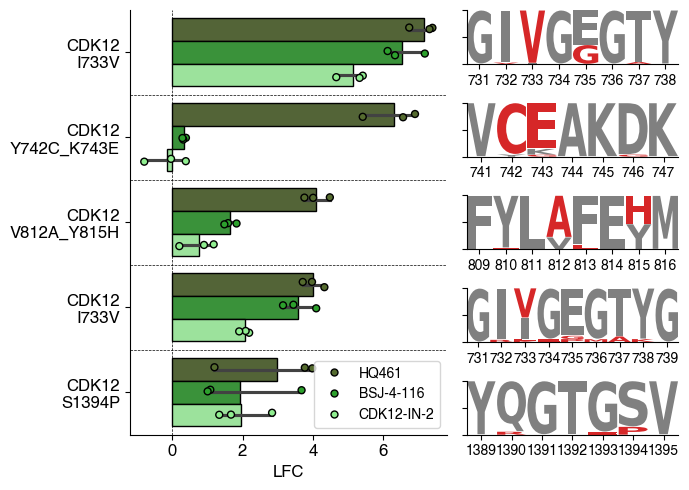

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 5))

num_to_plot = 5
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):
    merge = SAV_ABE2
    gRNA_id = val
    context_size=1
    min_perc = 2

    logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

    ax1 = plt.subplot(gs[i,1])
    
    ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
    ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
    ss_logo.ax.set_yticks([0,50,100])
    ss_logo.ax.set_yticklabels([], fontsize=10);
    #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
    #ss_logo.ax.set_ylabel('Probability', fontsize=14)

    ss_logo.ax.get_xticks()

    d_nonzero = d4[d4['%Reads']>0]


    for i, val in d_nonzero.iterrows():
        alt = val['alt']
        loc = val['codon']
        pp = val['%Reads']
        ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

    ss_logo.style_spines(spines=['right', 'top'], visible=False)

    subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
    

    g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
    hg = list(subset2['HGVSp'])[0]
    top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower right')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/hq461_top_vars.pdf', transparent=True)

# ABE and CBE merge

In [458]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

condition = 'BSJ-4-116'
FDR_cutoff = 0.1

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

data = pd.concat((data_ABE, data_CBE))


all_conditions = ['BSJ-4-116', 'CDK12-IN-2', 'HQ461']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [ ]:
topx

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,LFC_avg_CBE_T0,LFC_median_CBE_T0,p_CBE_BSJ-4-116,FDR_CBE_BSJ-4-116,p_CBE_CDK12-IN-2,FDR_CBE_CDK12-IN-2,p_CBE_HQ461,p_CBE_T0,FDR_CBE_T0,gRNA_id2
0,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2232_ABE
1,gRNA_CDK12_targ_3351,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,41.689468,1363.0,...,1.158584,1.635614,1.836945e-03,0.351951,7.202656e-07,0.000877,4.102532e-10,0.113926,0.641774,gRNA_CDK12_targ_3351_CBE
2,gRNA_CDK12_targ_2238,CDK12,targeting,0.386960,0.288864,0.312813,0.329546,0.312813,29.924039,563.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2238_ABE
3,gRNA_CDK12_targ_3395,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,61.671464,1657.0,...,1.110857,1.406557,3.311692e-01,0.999995,5.338094e-01,0.971536,4.102532e-10,0.137709,0.683302,gRNA_CDK12_targ_3395_CBE
4,gRNA_CDK12_targ_3394,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,5.173406,139.0,...,1.353074,1.308316,7.484682e-09,0.000036,1.669686e-08,0.000038,8.082480e-09,0.060805,0.501694,gRNA_CDK12_targ_3394_CBE
5,gRNA_CDK12_targ_3396,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,55.851040,1826.0,...,0.388700,0.572441,4.473734e-01,0.999995,2.929773e-02,1.000000,8.082480e-09,0.579052,0.999993,gRNA_CDK12_targ_3396_CBE
6,gRNA_CDK13_targ_5767,CDK13,targeting,NaN,NaN,NaN,NaN,NaN,2.950841,90.0,...,2.097245,1.947008,4.832778e-03,0.454503,6.629044e-03,0.319507,7.068638e-05,0.004315,0.187559,gRNA_CDK13_targ_5767_CBE
7,gRNA_CDK12_targ_3392,CDK12,targeting,1.827192,1.586179,1.481560,1.631643,1.586179,25.178391,515.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_3392_ABE
8,gRNA_CDK12_targ_2233,CDK12,targeting,3.445245,3.149981,4.093716,3.562981,3.445245,57.824745,1889.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2233_ABE
9,gRNA_CDK12_targ_3874,CDK12,targeting,3.677316,1.005323,1.080880,1.921173,1.080880,63.557104,1504.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_3874_ABE


In [459]:
topx = subset[:20].reset_index(drop=True)

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
true_name = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

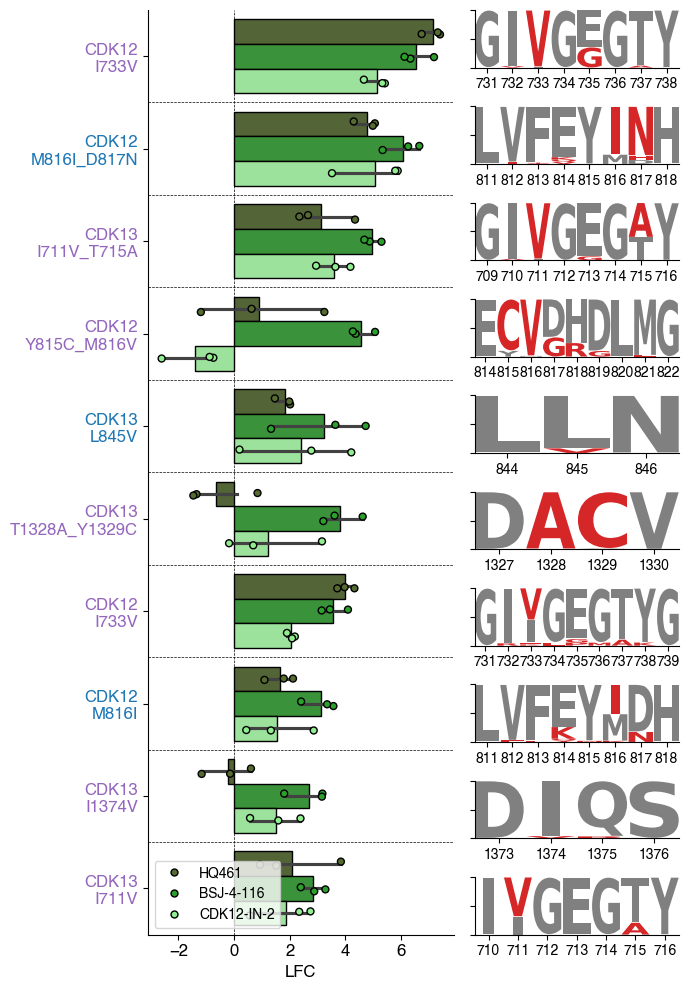

In [460]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 10))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE2[(CBE2['gRNA_id']==gRNA_id) & (CBE2['HGVSp']!='WT') & (CBE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower left')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

#fig.savefig('../../figures/bsj_top_vars.pdf', transparent=True)

# Subpool 2 validation gRNAs

In [313]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

condition = 'HQ461'
data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data = pd.concat((data_ABE, data_CBE))

In [314]:
import re

def extract_numbers(text):
    """Extracts all numbers from the given text."""
    return [int(i) for i in re.findall(r'\d+', text)][0]

def top_HGVSp_compiler(edit):
    """ 
    Input = HGVSp dataframe
    output = top HGVSp, Codon, & WT percentage
    """

    non_WT = edit[edit['HGVSp']!='WT']
    WT = edit[edit['HGVSp']=='WT'].rename(columns = {'%Reads':'WT_perc'})
    WT = WT[['gRNA_id', 'WT_perc']]

    top_per_group = non_WT.groupby('gRNA_id').apply(lambda x: x.nlargest(1, '%Reads'))
    top_per_group = top_per_group.reset_index(drop=True)
    new = pd.merge(top_per_group, WT, on='gRNA_id', how='outer')
    new['HGVSp'] = new['HGVSp'].fillna('WT')
    new = new.fillna(0)

    codon = []
    for i, val in new.iterrows():
        a = val['HGVSp']
        if a=='WT':
            codon.append(0)
        else:
            out = extract_numbers(a)
            codon.append(int(out))

    new['Codon'] = codon

    return new

In [315]:
samples = ['CBE_subpool1', 'ABE_subpool1', 'CBE_CDK12_13', 'ABE_CDK12_13', 'CBE_CDK2_4_6', 'ABE_CDK2_4_6']

e_holder = []
for sample in samples:
    edit = pd.read_csv(f'../../screening_data/04_editing/{sample}_HGVSp.zip')
    e1 = top_HGVSp_compiler(edit)
    e_holder.append(e1)

top_edit_dict = dict(zip(samples, e_holder))

In [316]:
data_ABE = pd.merge(data_ABE, top_edit_dict['ABE_CDK12_13'], on='gRNA_id', how='outer')
data_CBE = pd.merge(data_CBE,  top_edit_dict['CBE_CDK12_13'], on='gRNA_id', how='outer')

conditions = ['HQ461', 'CDK12-IN-2', 'BSJ-4-116']
for condition in conditions:
    data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
    data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})
data = pd.concat((data_ABE, data_CBE))

(0.0, 1490.0)

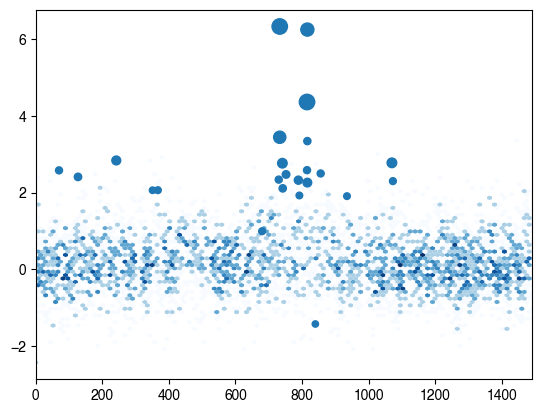

In [343]:
c12 = data[(data['Gene']=='CDK12') & (data['classification']=='targeting')]
plt.hexbin(c12['Codon'], c12['LFC_median_BSJ-4-116'], linewidths=0, cmap='Blues', gridsize=(100,50), bins='log')

top = c12[c12['FDR_BSJ-4-116']<.1]
plt.scatter(top['Codon'], top['LFC_median_BSJ-4-116'], s=20*(-np.log10(top['FDR_BSJ-4-116'])))
plt.xlim(0,max(c12['Codon']))

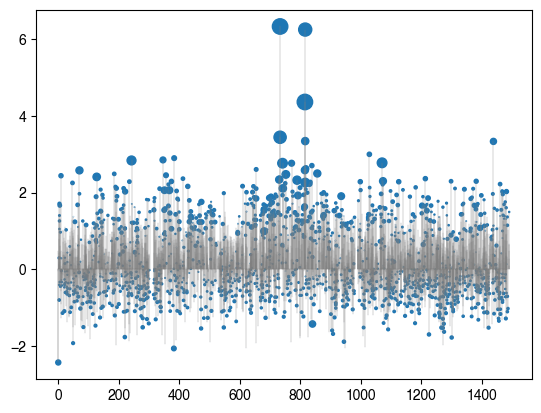

In [ ]:
plt.scatter(c12['Codon'], c12['LFC_median_BSJ-4-116'], s=20*(-np.log10(c12['FDR_BSJ-4-116'])))
plt.plot([c12['Codon'],c12['Codon']], [[0]*len(c12), c12['LFC_median_BSJ-4-116']],linewidth=.25, color='grey');

#plt.savefig('')
#plt.savefig('../../figures/test_noraster.pdf')#, dpi=300)

In [133]:

def cc(subset):

    subset = subset[subset['Gene']==gene].reset_index(drop=True)

    all = []
    h_only = []

    double = []
    single = []

    c_only = []
    b_only = []
    h_c = []
    h_b =[]
    c_b = []

    for i, val in subset.iterrows():
        conditions = ['HQ461', 'CDK12-IN-2', 'BSJ-4-116']
        k = val['HGVSp']
        truth_list = []
        counter = 0
        for condition in conditions:
            if val[f'FDR_{condition}']<FDR_cutoff:
                truth_list.append(True)
                counter+=1
            else:
                truth_list.append(False)
        
        print(f'{val["Gene"]} {val["HGVSp"]} {counter} {truth_list}' )
        
        if (truth_list[0]==True) & (truth_list[1]==True) & (truth_list[2]==True):
            all.append(k)
        
        if (truth_list[0]==True) & (truth_list[1]==False) & (truth_list[2]==False):
            h_only.append(k)

        if (truth_list[0]==True) & (truth_list[1]==True) & (truth_list[2]==False):
            h_c.append(k)
            double.append(k)
        
        if (truth_list[0]==True) & (truth_list[1]==False) & (truth_list[2]==True):
            h_b.append(k)
            double.append(k)

        if (truth_list[0]==False) & (truth_list[1]==True) & (truth_list[2]==False):
            c_only.append(k)
            single.append(k)
        
        if (truth_list[0]==False) & (truth_list[1]==True) & (truth_list[2]==True):
            c_b.append(k)
            double.append(k)
        
        if (truth_list[0]==False) & (truth_list[1]==False) & (truth_list[2]==True):
            b_only.append(k)
            single.append(k)
        
    print(f'\n{gene}')
    print(f'all {all}')
    print(f'HQ461 {h_only}')
    print(f'HQ461 + CDK12-IN-2 {h_c}')
    print(f'HQ461 + BSJ-4-116 {h_b}')
    print(f'CDK12-IN-2 {c_only}')
    print(f'CDK12-IN-2 + BSJ-4-116 {c_b}')
    print(f'BSJ-4-116 {b_only}')

    return all, h_only, double, single


FDR_cutoff = .01
subset = data[(data['FDR_BSJ-4-116']<FDR_cutoff)|(data['FDR_HQ461']<FDR_cutoff)|(data['FDR_CDK12-IN-2']<FDR_cutoff)]
gene = 'CDK12'
c12_v1 = cc(subset)
print('\n')

FDR_cutoff = .01
subset = data[(data['FDR_BSJ-4-116']<FDR_cutoff)|(data['FDR_HQ461']<FDR_cutoff)|(data['FDR_CDK12-IN-2']<FDR_cutoff)]
gene = 'CDK13'
c13_v1 = cc(subset)



CDK12 I733V 3 [True, True, True]
CDK12 I733V 2 [True, False, True]
CDK12 Y742C_K743E 1 [True, False, False]
CDK12 Y815C_M816V 1 [False, False, True]
CDK12 T1070E_T1071K_S1072L 1 [False, False, True]
CDK12 P1445* 1 [False, True, False]
CDK12 Y242H 1 [False, False, True]
CDK12 V741A 1 [False, False, True]
CDK12 V812A_Y815H 1 [True, False, False]
CDK12 S367F 1 [False, True, False]
CDK12 G731K 2 [True, True, False]
CDK12 M816I_D817N 3 [True, True, True]
CDK12 G822K 1 [True, False, False]
CDK12 G822E 1 [True, False, False]

CDK12
all ['I733V', 'M816I_D817N']
HQ461 ['Y742C_K743E', 'V812A_Y815H', 'G822K', 'G822E']
HQ461 + CDK12-IN-2 ['G731K']
HQ461 + BSJ-4-116 ['I733V']
CDK12-IN-2 ['P1445*', 'S367F']
CDK12-IN-2 + BSJ-4-116 []
BSJ-4-116 ['Y815C_M816V', 'T1070E_T1071K_S1072L', 'Y242H', 'V741A']


CDK13 I711V_T715A 2 [False, True, True]
CDK13 I711V 1 [False, False, True]
CDK13 M818V_R819G 1 [False, True, False]
CDK13 Q820R 1 [False, True, False]
CDK13 T1328A_Y1329C 1 [False, False, True]
CDK13 L

In [180]:
FDR_cutoff = .1
subset = data[((data['FDR_BSJ-4-116']<FDR_cutoff) & (data['LFC_median_BSJ-4-116']>0))|((data['FDR_HQ461']<FDR_cutoff) & (data['LFC_median_HQ461']>0))|((data['FDR_CDK12-IN-2']<FDR_cutoff) & (data['LFC_median_CDK12-IN-2']>0))]
gene = 'CDK12'
c12_v2 = cc(subset)
print('\n')

FDR_cutoff = .1
subset = data[((data['FDR_BSJ-4-116']<FDR_cutoff) & (data['LFC_median_BSJ-4-116']>0))|((data['FDR_HQ461']<FDR_cutoff) & (data['LFC_median_HQ461']>0))|((data['FDR_CDK12-IN-2']<FDR_cutoff) & (data['LFC_median_CDK12-IN-2']>0))]
gene = 'CDK13'
c13_v2 = cc(subset)

CDK12 R221G 1 [False, True, False]
CDK12 K351E 1 [False, False, True]
CDK12 K446E 1 [False, True, False]
CDK12 N474G 1 [False, True, False]
CDK12 I730V 1 [False, False, True]
CDK12 I733V 3 [True, True, True]
CDK12 I733V 3 [True, True, True]
CDK12 Y742C_K743E 1 [True, False, False]
CDK12 L752V 1 [False, False, True]
CDK12 D761G_N762D 1 [False, True, False]
CDK12 M789V_K790E 1 [False, False, True]
CDK12 I792V 2 [False, True, True]
CDK12 Y815C_M816V 1 [False, False, True]
CDK12 M816V_D817G 1 [False, False, True]
CDK12 T1070E_T1071K_S1072L 1 [False, False, True]
CDK12 E1222G 1 [False, True, False]
CDK12 P1445* 1 [False, True, False]
CDK12 Y1468C 1 [False, True, False]
CDK12 L70S 1 [False, False, True]
CDK12 Q127H 2 [False, True, True]
CDK12 Y242H 2 [False, True, True]
CDK12 S367Y 1 [False, False, True]
CDK12 L680P_S681P 1 [False, False, True]
CDK12 C706R 1 [False, True, False]
CDK12 V741A 1 [False, False, True]
CDK12 Y742H 1 [False, False, True]
CDK12 V812A_Y815H 1 [True, False, False]
CDK

In [181]:
c13_v2

(['I711V_T715A', 'V1001A'],
 ['K566G', 'Q1015*', 'Q1189*', 'E743K_G744S', 'E803K'],
 ['D659G', 'I711V', 'I926V', 'L907P_F908L', 'S1004P', 'L1099P', 'L845V'],
 ['S409Y',
  'D535G',
  'D623G_S624G',
  'K663G_S664G',
  'K734E',
  'D739G_N740D',
  'M818V_R819G',
  'Q820R',
  'E823G',
  'I851V',
  'I851M',
  'S932G',
  'Q955R_Y956C',
  'K959E',
  'E963*',
  'R1044G',
  'Q1100R',
  'Q1123K',
  'E1272G_E1273G',
  'T1328A_Y1329C',
  'I1374V',
  'A461T',
  'G530*',
  'L655P',
  'I710T_E713Q',
  'Y720H',
  'P746R_I747Y_T748Q_A749L_I750E_R751K',
  'I765T',
  'L801P',
  'L806S',
  'V807A',
  'L825P',
  'I851T',
  'I851T',
  'I851T',
  'G857R',
  'V874A',
  'L884P_L885P',
  'V897A_W898R',
  'C900R',
  'C900R',
  'L904P',
  'F908S',
  'I913T',
  'I913T_F914L',
  'I926T',
  'V937A_W938R',
  'V937A_W938R',
  'L944P',
  'M950T',
  'I967T',
  'L974P',
  'C987R',
  'L993P',
  'L998P',
  'L1047S_S1048P',
  nan,
  'A777V',
  'I913V',
  'N1115K',
  'Q762H',
  'D855N',
  'G905S',
  'E906K',
  'E924Q',
  'G93

In [202]:
def extract_numbers2(text):
    """Extracts all numbers from the given text."""
    k = [int(i) for i in re.findall(r'\d+', text)]
    if len(k)==1:
        return [k[0]]
    elif len(k)==2:
        return k[0], k[1]
    elif len(k)==3:
        return k[0], k[1], k[2]
    elif len(k)==4:
        return k[0], k[1], k[2], k[3]
    elif len(k)==5:
        return k[0], k[1], k[2], k[3], k[4]
    elif len(k)==6:
        return k[0], k[1], k[2], k[3],k[4],k[5]

jj = []
for k in c13_v2:
    k = [i for i in k if type(i)==str]
    j = [extract_numbers2(i) for i in k]
    jj.append(j)

m_list2 = []
for j in jj:
    m_list = []
    for i in j:
        if len(i)>1:
            for k in i:
                m_list.append(k)
        else:
            m_list.append(i[0])
    m_list2.append(list(np.unique(m_list)))

print([len(i) for i in m_list2])
print(m_list2)
#all, h_only, double, single

for k in m_list2[3]:
    if (k in m_list2[0]) or (k in m_list2[1]) or (k in m_list2[2]):
        if k in m_list2[1]:
            m_list2[2].append(k)
        m_list2[3].remove(k)
        print(k)

for k in m_list2[1]:
    if (k in m_list2[0]) or (k in m_list2[2]) or (k in m_list2[3]):
        m_list2[1].remove(k)

for k in m_list2[2]:
    if (k in m_list2[0]) or (k in m_list2[1]):
        m_list2[2].remove(k)

    
    
print([len(i) for i in m_list2])
print(m_list2)

[3, 6, 8, 76]
[[711, 715, 1001], [566, 743, 744, 803, 1015, 1189], [659, 711, 845, 907, 908, 926, 1004, 1099], [409, 461, 530, 535, 623, 624, 655, 663, 664, 710, 713, 720, 734, 739, 740, 746, 747, 748, 749, 750, 751, 762, 765, 777, 801, 806, 807, 818, 819, 820, 823, 825, 851, 855, 857, 874, 884, 885, 897, 898, 900, 904, 905, 906, 908, 913, 914, 924, 926, 931, 932, 937, 938, 944, 946, 950, 955, 956, 959, 963, 967, 974, 987, 993, 998, 1044, 1047, 1048, 1100, 1115, 1123, 1272, 1273, 1328, 1329, 1374]]
908
926
[3, 6, 7, 74]
[[711, 715, 1001], [566, 743, 744, 803, 1015, 1189], [659, 845, 907, 908, 926, 1004, 1099], [409, 461, 530, 535, 623, 624, 655, 663, 664, 710, 713, 720, 734, 739, 740, 746, 747, 748, 749, 750, 751, 762, 765, 777, 801, 806, 807, 818, 819, 820, 823, 825, 851, 855, 857, 874, 884, 885, 897, 898, 900, 904, 905, 906, 913, 914, 924, 931, 932, 937, 938, 944, 946, 950, 955, 956, 959, 963, 967, 974, 987, 993, 998, 1044, 1047, 1048, 1100, 1115, 1123, 1272, 1273, 1328, 1329, 1374]]

In [197]:
type(c13_v2[3][-11])

float

In [206]:
print(m_list2[0])

[711, 715, 1001]


In [173]:
m_list2

[[733, 816, 817],
 [394, 743, 812, 822, 1253, 1394],
 [127, 242, 731, 792, 742, 815],
 [70,
  221,
  263,
  351,
  367,
  446,
  473,
  474,
  680,
  681,
  706,
  730,
  741,
  752,
  761,
  762,
  763,
  764,
  765,
  789,
  790,
  816,
  818,
  856,
  935,
  1036,
  1067,
  1070,
  1071,
  1072,
  1073,
  1222,
  1271,
  1445,
  1468]]

In [ ]:
#all, h_only, double, single

# ChimeraX commands

CDK12
ALL: #5/H:733,816,817
HQ461-only: #5/H:742,743,812,822
CDK12-IN only: #5/H:1445,367
BSJ only: #5/H:1070,1071,1072,242,741

HQ + BS: #5/H:815
HQ + C: #5/H:731
C + BS: #5/H:

SINGLET: #5/H:70, 221, 263, 351, 367, 446, 473, 474, 680, 681, 706, 730, 741, 752, 761, 762, 763, 764, 765, 789, 790, 816, 818, 856, 935, 1036, 1067, 1070, 1071, 1072, 1073, 1222, 1271, 1445, 1468

DOUBLET: #5/H:127, 242, 731, 792, 742, 815
HQ-ONLY: #5/H:394, 743, 812, 822, 1253, 1394
ALL: #5/H:733, 816, 817


CDK13:

SINGLET: #6/C:409, 461, 530, 535, 623, 624, 655, 663, 664, 710, 713, 720, 734, 739, 740, 746, 747, 748, 749, 750, 751, 762, 765, 777, 801, 806, 807, 818, 819, 820, 823, 825, 851, 855, 857, 874, 884, 885, 897, 898, 900, 904, 905, 906, 913, 914, 924, 931, 932, 937, 938, 944, 946, 950, 955, 956, 959, 963, 967, 974, 987, 993, 998, 1044, 1047, 1048, 1100, 1115, 1123, 1272, 1273, 1328, 1329, 1374
DOUBLET: #6/C:659, 845, 907, 908, 926, 1004, 1099
HQ: #6/C:566, 743, 744, 803, 1015, 1189
ALL: #6/C:711, 715, 1001


CDK12-IN only: #6/C:818,819,820,907,908,967,1004,905
BSJ only: #6/C:1328,1329,913,914
C + BS: #6/C:711,715


ALL: SLATE
HQ461: goldenrod
single: salmon
double: red

HQ461-only: ORANGE
CDK12-IN only: YELLOW
BSJ only: BLUE

HQ + BS: PURPLE
HQ + C: GREY
C + BS: CYAN

In [ ]:
#CDK12
#

492      733.0
493      733.0
498      742.0
545      815.0
712     1070.0
1010    1445.0
1221     242.0
1612     741.0
1652     812.0
275      367.0
1611     731.0
1654     816.0
1655     822.0
1656     822.0
Name: Codon, dtype: float64

In [111]:
data['HGVSp']

0       M1V
1       N3D
2       N3D
3       N3G
4       N3G
       ... 
4863    NaN
4864    NaN
4865    NaN
4866    NaN
4867    NaN
Name: HGVSp, Length: 9736, dtype: object

In [564]:
cdk12_13_gRNAs = ['gRNA_CDK12_targ_3351',
'gRNA_CDK12_targ_3394',
'gRNA_CDK12_targ_3395',
'gRNA_CDK12_targ_3396',
'gRNA_CDK12_targ_2232',
'gRNA_CDK13_targ_4604',
'gRNA_CDK13_targ_4605',
'gRNA_CDK13_targ_4675']

type_list = ['CBE',
             'CBE',
             'CBE',
             'CBE',
             'ABE',
             'ABE',
             'ABE',
             'ABE']

t_dict = dict(zip(cdk12_13_gRNAs, type_list))


abe_guides = []
cbe_guides = []
for i in cdk12_13_gRNAs:
    if t_dict[i]=='ABE':
        abe_guides.append(i)
    elif t_dict[i]=='CBE':
        cbe_guides.append(i)

In [565]:
a1 = data_ABE[data_ABE['gRNA_id'].isin(abe_guides)]
c1 = data_CBE[data_CBE['gRNA_id'].isin(cbe_guides)]

subset = pd.concat((a1, c1)).sort_values(by=f'LFC_median_{condition}', ascending=False).reset_index(drop=True)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [574]:
subset

,gRNA_id,Gene,classification,ABE_BSJ-4-116_REP1,ABE_BSJ-4-116_REP2,ABE_BSJ-4-116_REP3,LFC_avg_ABE_BSJ-4-116,LFC_median_ABE_BSJ-4-116,base_RPM,base_RAW,...,LFC_avg_CBE_T0,LFC_median_CBE_T0,p_CBE_BSJ-4-116,FDR_CBE_BSJ-4-116,p_CBE_CDK12-IN-2,FDR_CBE_CDK12-IN-2,p_CBE_HQ461,p_CBE_T0,FDR_CBE_T0,gRNA_id2
0,gRNA_CDK12_targ_2232,CDK12,targeting,6.125533,6.335788,7.184101,6.548474,6.335788,73.276138,3369.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK12_targ_2232_ABE
1,gRNA_CDK12_targ_3351,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,41.689468,1363.0,...,1.158584,1.635614,1.836945e-03,0.351951,7.202656e-07,0.000877,4.102532e-10,0.113926,0.641774,gRNA_CDK12_targ_3351_CBE
2,gRNA_CDK12_targ_3395,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,61.671464,1657.0,...,1.110857,1.406557,3.311692e-01,0.999995,5.338094e-01,0.971536,4.102532e-10,0.137709,0.683302,gRNA_CDK12_targ_3395_CBE
3,gRNA_CDK12_targ_3394,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,5.173406,139.0,...,1.353074,1.308316,7.484682e-09,0.000036,1.669686e-08,0.000038,8.082480e-09,0.060805,0.501694,gRNA_CDK12_targ_3394_CBE
4,gRNA_CDK12_targ_3396,CDK12,targeting,NaN,NaN,NaN,NaN,NaN,55.851040,1826.0,...,0.388700,0.572441,4.473734e-01,0.999995,2.929773e-02,1.000000,8.082480e-09,0.579052,0.999993,gRNA_CDK12_targ_3396_CBE
5,gRNA_CDK13_targ_4604,CDK13,targeting,4.873180,4.681693,5.298524,4.951133,4.873180,96.766262,4449.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK13_targ_4604_ABE
6,gRNA_CDK13_targ_4675,CDK13,targeting,0.066350,1.116631,0.338507,0.507162,0.338507,26.009523,532.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK13_targ_4675_ABE
7,gRNA_CDK13_targ_4605,CDK13,targeting,2.882840,2.399391,3.284003,2.855411,2.882840,96.587557,2436.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK13_targ_4605_ABE


In [581]:
top_hg = []
guides = list(subset['gRNA_id'])
editors = list(subset['Editor'])
for i, gRNA_id in enumerate(guides):

    if editors[i]=='ABE':
        subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
    
        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':

        subset2 = CBE2[(CBE2['gRNA_id']==gRNA_id) & (CBE2['HGVSp']!='WT') & (CBE2['%Reads']>=min_perc)]
        
        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]

        top_hg.append(f'{g}\n{hg}')

In [582]:
top_hg

['CDK12\nI733V',
 'CDK12\nG731K',
 'CDK12\nG822K',
 'CDK12\nM816I_D817N',
 'CDK12\nG822E',
 'CDK13\nI711V_T715A',
 'CDK13\nM818V_R819G',
 'CDK13\nI711V']

In [575]:
top_hg

['CDK12\nI733V',
 'CDK12\nG731K',
 'CDK12\nG822K',
 'CDK12\nM816I_D817N',
 'CDK12\nG822E',
 'CDK13\nI711V_T715A',
 'CDK13\nM818V_R819G',
 'CDK13\nI711V']

In [567]:
topx = subset.reset_index(drop=True)

conditions = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
true_name = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

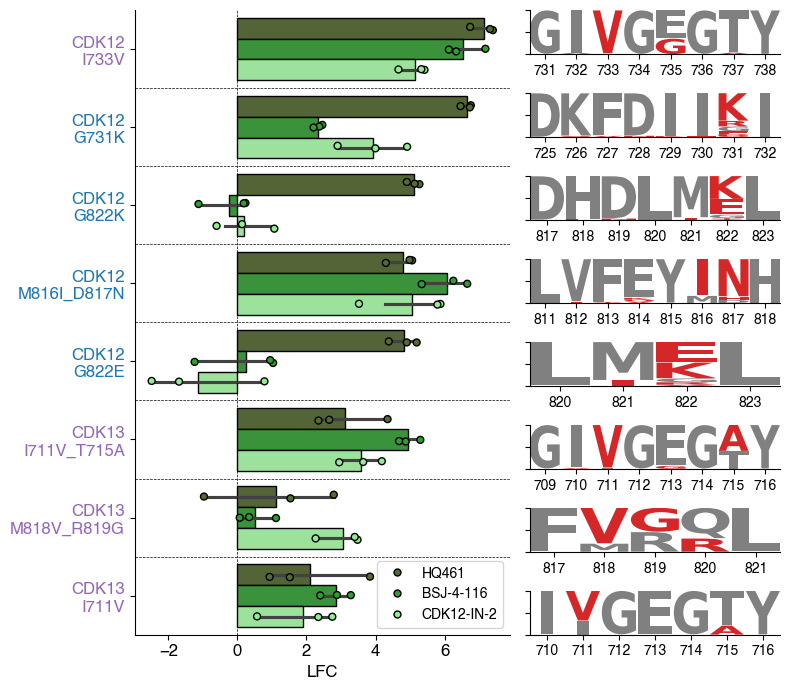

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(8, 7))

num_to_plot = len(topx)
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE2[(CBE2['gRNA_id']==gRNA_id) & (CBE2['HGVSp']!='WT') & (CBE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower right')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/cdk12_13_validation_guides.pdf', transparent=True)

# Subpool 2 

In [370]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK12_13_CBE_barcode_DMSO_base.csv')

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

FDR_cutoff = 0.1
condition = 'CDK12-IN-2'

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data = pd.concat((data_ABE, data_CBE))


all_conditions = ['HQ461', 'CDK12-IN-2', 'BSJ-4-116']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [371]:
topx = subset[:12].reset_index(drop=True)

conditions = ['HQ461', 'CDK12-IN-2', 'BSJ-4-116']
true_name  =['HQ461', 'CDK12-IN-2', 'BSJ-4-116']

condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

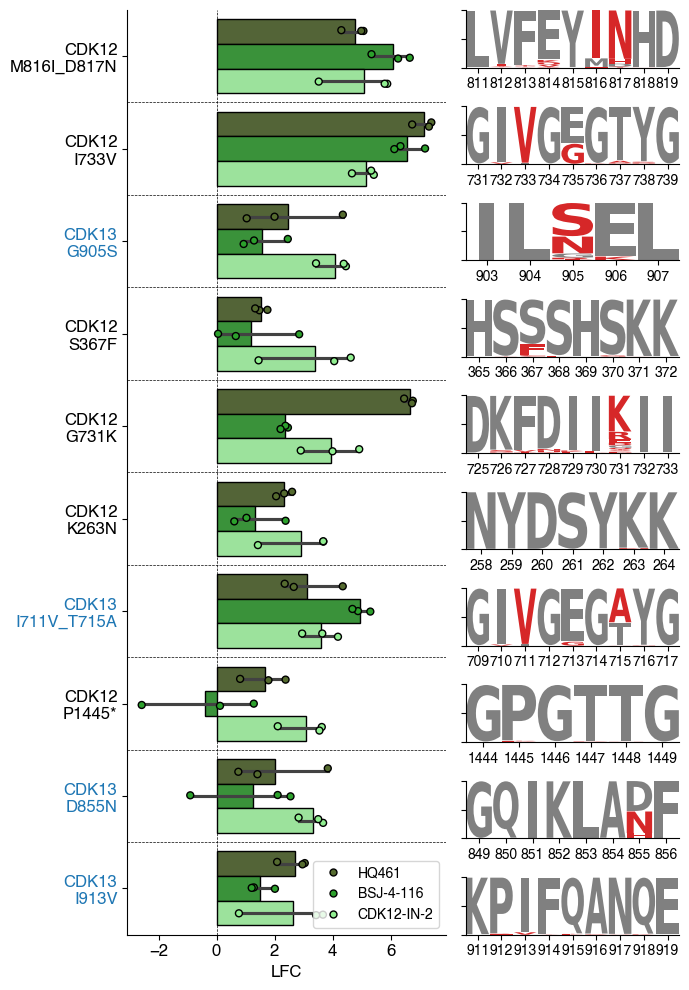

In [376]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 10))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
hue_order = ['HQ461', 'BSJ-4-116', 'CDK12-IN-2']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
g_list = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = .15

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE2[(ABE2['gRNA_id']==gRNA_id) & (ABE2['HGVSp']!='WT') & (ABE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')
        g_list.append(g)

        
    elif editors[i]=='CBE':
        merge = SAV_CBE2
        gRNA_id = val[:-4]
        context_size=1
        min_perc = .15

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE2[(CBE2['gRNA_id']==gRNA_id) & (CBE2['HGVSp']!='WT') & (CBE2['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')
        g_list.append(g)



ax0.set_yticklabels(top_hg)

color_dict = {'CDK12':'black', 'CDK13':'tab:blue'}
for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    tick_label.set_color(color_dict[g_list[i]])
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower right')
#ax0.get_legend().remove()
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

#fig.savefig('../../figures/top_CDK12_in_2_vars.pdf', transparent=True)

# Subpool 1

In [4]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')


FDR_cutoff = 0.1
condition = 'KI-CDK9d-32N_5000nM'

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'KB-0742_1500nM']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]



In [5]:
subset = subset[subset['Gene']=='CDK9']
topx = subset[:12].reset_index(drop=True)

conditions = ['KI-CDK9d-32_100nM', 'KI-CDK9d-32_1000nM', 'KI-CDK9d-32N_1250nM', 'KI-CDK9d-32N_5000nM', 'KB-0742_1500nM']
true_name  = ['KI-CDK9d-32 100nM', 'KI-CDK9d-32 1,000nM', 'KI-CDK9d-32N 1,250nM', 'KI-CDK9d-32N 5,000nM', 'KB-0742 1,500nM']

condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

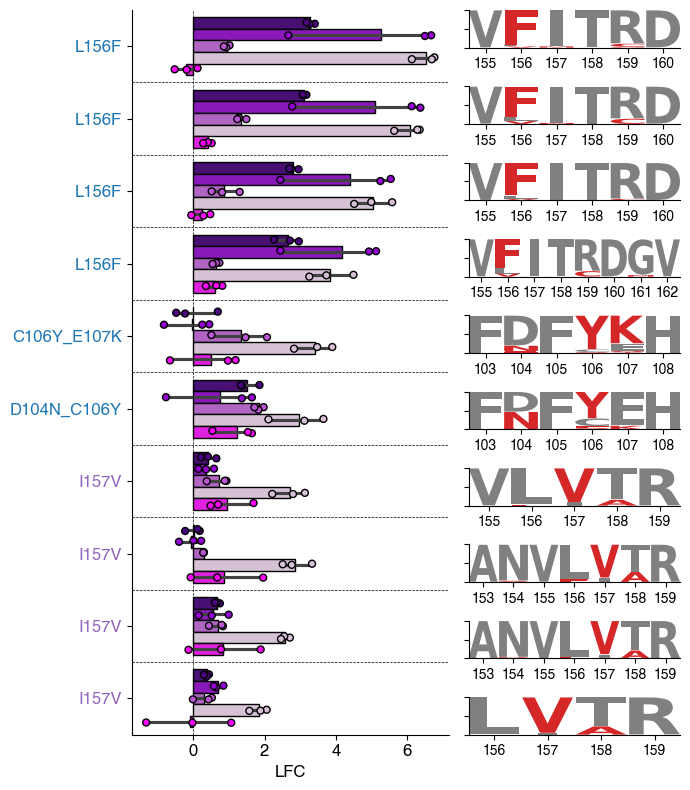

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 8))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
palette = ['indigo', 'darkviolet', 'mediumorchid', 'thistle', 'magenta']
hue_order = ['KI-CDK9d-32 100nM', 'KI-CDK9d-32 1,000nM', 'KI-CDK9d-32N 1,250nM', 'KI-CDK9d-32N 5,000nM', 'KB-0742 1,500nM']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        #top_hg.append(f'{g}\n{hg}')
        top_hg.append(f'{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE1[(CBE1['gRNA_id']==gRNA_id) & (CBE1['HGVSp']!='WT') & (CBE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        #top_hg.append(f'{g}\n{hg}')
        top_hg.append(f'{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


#ax0.legend(loc='lower right', fontsize=8)
#ax0.get_legend().remove()
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
fig.savefig('../../figures/cdk9_top_vars_v3.pdf', transparent=True)

In [433]:
plot_df

,gRNA_id,gRNA_id2,Replicate,LFC,Condition,Editor
11,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,3,6.758645,"KI-CDK9d-32N 5,000nM",CBE
10,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,2,6.686852,"KI-CDK9d-32N 5,000nM",CBE
3,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,1,6.668399,"KI-CDK9d-32 1,000nM",CBE
4,gRNA_CDK9_targ_1200,gRNA_CDK9_targ_1200_CBE,2,6.493467,"KI-CDK9d-32 1,000nM",CBE
19,gRNA_CDK9_targ_1199,gRNA_CDK9_targ_1199_CBE,2,6.365646,"KI-CDK9d-32 1,000nM",CBE
...,...,...,...,...,...,...
103,gRNA_CDK9_targ_1468,gRNA_CDK9_targ_1468_ABE,2,-1.437810,"KB-0742 1,500nM",ABE
88,gRNA_CDK19_targ_6713,gRNA_CDK19_targ_6713_ABE,2,-1.473799,"KB-0742 1,500nM",ABE
144,gRNA_CDK9_targ_1210,gRNA_CDK9_targ_1210_ABE,1,-1.654135,"KI-CDK9d-32N 5,000nM",ABE
99,gRNA_CDK9_targ_1468,gRNA_CDK9_targ_1468_ABE,1,-2.099948,"KI-CDK9d-32N 5,000nM",ABE


# Subpool 1 CDK8/19

In [359]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/ABE_subpool1_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CBE_subpool1_barcode_DMSO_base.csv')


FDR_cutoff = 0.1
condition = 'SEL120_4000nM'

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['SEL120_4000nM', 'Senexin B_2000nM', 'Senexin B_15000nM']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [360]:
subset

,gRNA_id,Gene,classification,KB-0742_1500nM_REP1,KB-0742_1500nM_REP2,KB-0742_1500nM_REP3,LFC_avg_KB-0742_1500nM,LFC_median_KB-0742_1500nM,base_RPM,base_RAW,...,p_Senexin B_15000nM,FDR_Senexin B_15000nM,p_Senexin B_2000nM,FDR_Senexin B_2000nM,p_T0,FDR_T0,p_Plasmid,FDR_Plasmid,Editor,gRNA_id2
2136,gRNA_CDK19_targ_6670,CDK19,targeting,0.717094,-0.385695,2.033722,0.788374,0.717094,2.178734,110.0,...,0.466949,0.892717,0.000472,0.075826,0.000226,0.006109,0.000100,0.006499,ABE,gRNA_CDK19_targ_6670_ABE
2132,gRNA_CDK19_targ_6666,CDK19,targeting,-0.032823,-0.867673,0.312617,-0.195960,-0.032823,4.456502,240.0,...,0.193955,0.758400,0.110014,0.890094,0.024841,0.132971,0.000100,0.006499,ABE,gRNA_CDK19_targ_6666_ABE
2135,gRNA_CDK19_targ_6669,CDK19,targeting,-0.022682,-0.541364,1.512807,0.316254,-0.022682,8.160350,412.0,...,0.000005,0.004955,0.000079,0.040205,0.010989,0.077148,0.000100,0.006499,ABE,gRNA_CDK19_targ_6669_ABE
833,gRNA_CDK8_targ_834,CDK8,targeting,-0.430484,-1.254108,0.478462,-0.402043,-0.430484,73.354546,4152.0,...,0.102354,0.636952,0.024003,0.334323,0.008434,0.064860,0.037296,0.322211,ABE,gRNA_CDK8_targ_834_ABE
2328,gRNA_CDK19_targ_6862,CDK19,targeting,-1.344662,1.985555,0.338521,0.326472,0.338521,5.980857,259.0,...,0.000030,0.061873,0.094747,0.916597,0.090572,0.287847,0.000100,0.024816,CBE,gRNA_CDK19_targ_6862_CBE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,gRNA_CDK7_targ_257,CDK7,targeting,-1.519203,-1.965331,-0.997152,-1.493895,-1.519203,312.262511,12913.0,...,0.001997,0.194703,0.000221,0.081589,0.000299,0.012005,0.000100,0.000975,CBE,gRNA_CDK7_targ_257_CBE
1934,gRNA_CDK19_targ_6468,CDK19,targeting,-1.261786,-1.174442,-1.726527,-1.387585,-1.261786,144.274082,5825.0,...,0.001423,0.149445,0.006484,0.236005,0.002405,0.032184,0.000100,0.000975,CBE,gRNA_CDK19_targ_6468_CBE
267,gRNA_CDK7_targ_268,CDK7,targeting,-1.418683,-2.233731,-1.255651,-1.636022,-1.418683,145.570960,6220.0,...,0.004987,0.304751,0.004797,0.226428,0.000003,0.000657,0.060794,0.241935,CBE,gRNA_CDK7_targ_268_CBE
138,gRNA_CDK7_targ_139,CDK7,targeting,-1.636383,-1.693404,-1.757119,-1.695636,-1.693404,190.394281,7858.0,...,0.025799,0.411886,0.083437,0.523775,0.173242,0.439477,0.000100,0.000975,CBE,gRNA_CDK7_targ_139_CBE


In [366]:
subset = subset[subset['Gene'].isin(['CDK8', 'CDK19'])]
topx = subset[:15].sort_values(by=f'LFC_median_{condition}', ascending=False).reset_index(drop=True)

conditions = ['SEL120_4000nM', 'Senexin B_2000nM', 'Senexin B_15000nM']
true_name  = ['SEL120 4,000 nM', 'Senexin B 2,000 nM', 'Senexin B 15,00 0nM']

condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

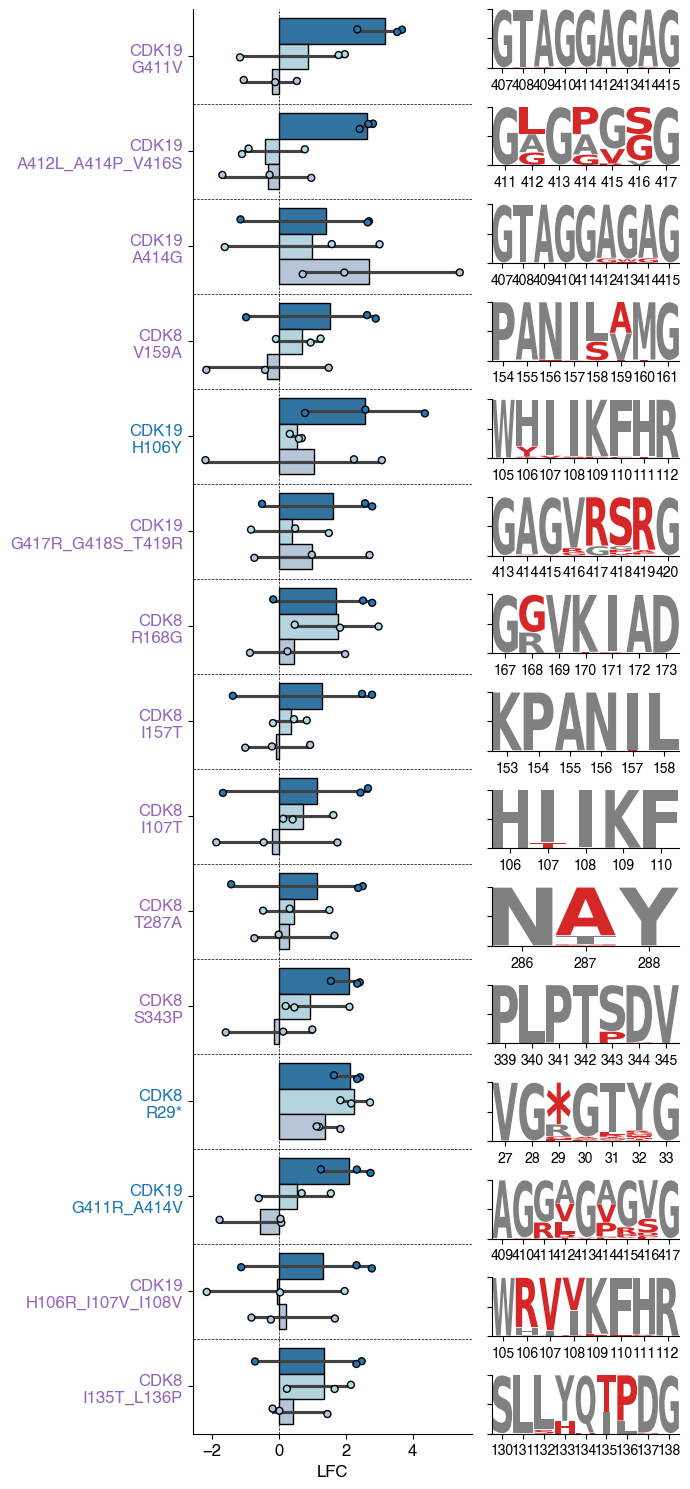

In [369]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 15))

num_to_plot = 15
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
palette = ['indigo', 'darkviolet', 'mediumorchid', 'thistle', 'magenta']

palette = ['tab:blue', 'lightblue', 'lightsteelblue']
hue_order = ['SEL120 4,000 nM', 'Senexin B 2,000 nM', 'Senexin B 15,00 0nM']


sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = .15

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')
        #top_hg.append(f'{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = .15

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE1[(CBE1['gRNA_id']==gRNA_id) & (CBE1['HGVSp']!='WT') & (CBE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')
        #top_hg.append(f'{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


#ax0.legend(loc='lower right', fontsize=8)
ax0.get_legend().remove()
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/cdk8_19_top_vars.pdf', transparent=True)

In [365]:
topx

,gRNA_id,Gene,classification,KB-0742_1500nM_REP1,KB-0742_1500nM_REP2,KB-0742_1500nM_REP3,LFC_avg_KB-0742_1500nM,LFC_median_KB-0742_1500nM,base_RPM,base_RAW,...,p_Senexin B_15000nM,FDR_Senexin B_15000nM,p_Senexin B_2000nM,FDR_Senexin B_2000nM,p_T0,FDR_T0,p_Plasmid,FDR_Plasmid,Editor,gRNA_id2
0,gRNA_CDK19_targ_6670,CDK19,targeting,0.717094,-0.385695,2.033722,0.788374,0.717094,2.178734,110.0,...,0.466949,0.892717,4.721794e-04,0.075826,0.000226,0.006109,0.000100,0.006499,ABE,gRNA_CDK19_targ_6670_ABE
1,gRNA_CDK19_targ_6666,CDK19,targeting,-0.032823,-0.867673,0.312617,-0.195960,-0.032823,4.456502,240.0,...,0.193955,0.758400,1.100140e-01,0.890094,0.024841,0.132971,0.000100,0.006499,ABE,gRNA_CDK19_targ_6666_ABE
2,gRNA_CDK19_targ_6669,CDK19,targeting,-0.022682,-0.541364,1.512807,0.316254,-0.022682,8.160350,412.0,...,0.000005,0.004955,7.898193e-05,0.040205,0.010989,0.077148,0.000100,0.006499,ABE,gRNA_CDK19_targ_6669_ABE
3,gRNA_CDK8_targ_834,CDK8,targeting,-0.430484,-1.254108,0.478462,-0.402043,-0.430484,73.354546,4152.0,...,0.102354,0.636952,2.400266e-02,0.334323,0.008434,0.064860,0.037296,0.322211,ABE,gRNA_CDK8_targ_834_ABE
4,gRNA_CDK19_targ_6862,CDK19,targeting,-1.344662,1.985555,0.338521,0.326472,0.338521,5.980857,259.0,...,0.000030,0.061873,9.474726e-02,0.916597,0.090572,0.287847,0.000100,0.024816,CBE,gRNA_CDK19_targ_6862_CBE
5,gRNA_CDK19_targ_6660,CDK19,targeting,1.104319,0.563220,1.890061,1.185867,1.104319,1.077704,61.0,...,0.000485,0.073580,5.258005e-02,0.402891,0.000166,0.005136,0.000100,0.006499,ABE,gRNA_CDK19_targ_6660_ABE
6,gRNA_CDK8_targ_569,CDK8,targeting,0.428162,-0.728245,1.475194,0.391704,0.428162,87.109751,4717.0,...,0.020912,0.615911,7.359777e-06,0.010046,0.000041,0.001885,0.085691,0.574785,ABE,gRNA_CDK8_targ_569_ABE
7,gRNA_CDK8_targ_831,CDK8,targeting,0.042354,-0.846077,0.339578,-0.154715,0.042354,35.216266,1778.0,...,0.335961,0.872086,1.621748e-01,0.597486,0.029570,0.148120,0.000100,0.006499,ABE,gRNA_CDK8_targ_831_ABE
8,gRNA_CDK8_targ_802,CDK8,targeting,0.177035,-1.169017,1.061751,0.023256,0.177035,40.900781,2065.0,...,0.095749,0.701678,2.050439e-02,0.334323,0.005033,0.048326,0.005499,0.099427,ABE,gRNA_CDK8_targ_802_ABE
9,gRNA_CDK8_targ_635,CDK8,targeting,-0.015346,-1.133492,1.071724,-0.025705,-0.015346,86.079804,4346.0,...,0.086265,0.825730,3.762261e-02,0.385609,0.010003,0.072695,0.037296,0.322211,ABE,gRNA_CDK8_targ_635_ABE


# SY-5609

In [16]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/SY_5609_CBE_barcode_DMSO_base.csv')

FDR_cutoff = 0.1
condition = 'SY-5609_10nM'

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['SY-5609_10nM', 'SY-5609_100nM']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting')].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [17]:
subset = subset[subset['Gene']=='CDK7']
topx = subset[:12].reset_index(drop=True)

conditions = ['SY-5609_10nM', 'SY-5609_100nM']
true_name  = ['SY-5609 10nM', 'SY-5609 100nM']

condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

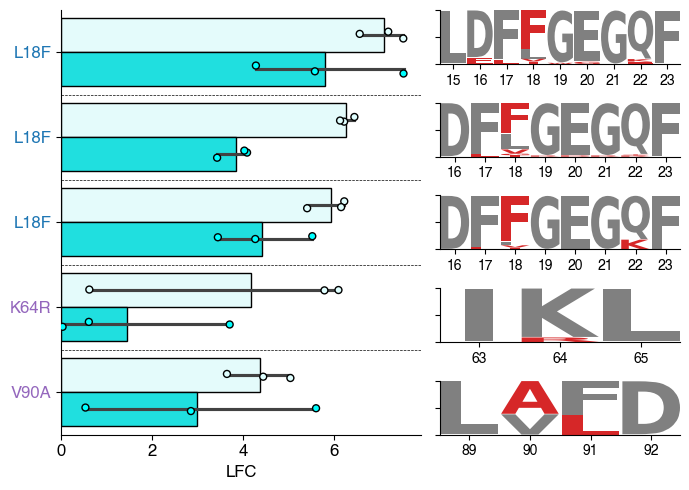

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 5))

num_to_plot = 5
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
palette = ['lightcyan', 'cyan']
hue_order = ['SY-5609 10nM', 'SY-5609 100nM']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        #top_hg.append(f'{g}\n{hg}')
        top_hg.append(f'{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE1[(CBE1['gRNA_id']==gRNA_id) & (CBE1['HGVSp']!='WT') & (CBE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        #top_hg.append(f'{g}\n{hg}')
        top_hg.append(f'{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


#ax0.legend(loc='lower right', fontsize=10)
ax0.get_legend().remove()
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/CDK7_top_vars_v2.pdf', transparent=True)

# Compound Mutant screen

In [83]:
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/proto_counts/DMSO_base/Compound_mutant_proto_DMSO_base.csv')


FDR_cutoff = .5
condition = 'KB_2000'

data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_CBE['Editor'] = 'CBE'

data = data_CBE

all_conditions = ['KB_2000', 'KB_4000']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting') & (data[f'LFC_median_{condition}']>0)].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [84]:
subset

,gRNA_id,Gene,classification,KB_2000_REP1,KB_2000_REP2,KB_2000_REP3,LFC_avg_KB_2000,LFC_median_KB_2000,base_RPM,base_RAW,...,p_KB_2000,FDR_KB_2000,p_KB_4000,FDR_KB_4000,p_T0,FDR_T0,p_Plasmid,FDR_Plasmid,Editor,gRNA_id2
1554,gRNA_CDK9_targ_1555,CDK9,targeting,0.799835,3.353693,3.972816,2.708782,3.353693,11.697819,292.0,...,0.000007,0.018607,7.751943e-02,0.999958,4.102532e-10,5.090869e-08,0.000100,0.004627,CBE,gRNA_CDK9_targ_1555_CBE
277,gRNA_CDK7_targ_278,CDK7,targeting,3.239491,0.911956,2.603298,2.251582,2.603298,55.003786,1753.0,...,0.001171,0.355107,4.102532e-10,0.000001,4.329348e-05,2.166280e-03,0.024698,0.441492,CBE,gRNA_CDK7_targ_278_CBE
19,gRNA_CDK7_targ_20,CDK7,targeting,2.574843,2.283461,3.108845,2.655717,2.574843,243.346215,11206.0,...,0.000334,0.118389,5.861105e-04,0.088893,1.613766e-02,1.711251e-01,0.408259,0.856694,CBE,gRNA_CDK7_targ_20_CBE
388,gRNA_CDK7_targ_389,CDK7,targeting,-0.148559,2.532534,3.556278,1.980084,2.532534,0.998923,46.0,...,0.001762,0.400850,4.179970e-07,0.000285,2.320192e-05,1.241985e-03,0.000100,0.004627,CBE,gRNA_CDK7_targ_389_CBE
1474,gRNA_CDK9_targ_1475,CDK9,targeting,2.268368,3.432553,0.215228,1.972050,2.268368,23.718758,691.0,...,0.001563,0.400850,2.119206e-01,0.999958,4.102532e-10,5.090869e-08,0.000100,0.004627,CBE,gRNA_CDK9_targ_1475_CBE
353,gRNA_CDK7_targ_354,CDK7,targeting,0.659004,3.479493,1.817457,1.985318,1.817457,164.518198,7380.0,...,0.001668,0.400850,6.136425e-05,0.020941,1.299928e-01,5.620842e-01,0.294371,0.932095,CBE,gRNA_CDK7_targ_354_CBE
1637,gRNA_CDK9_targ_1638,CDK9,targeting,4.395872,0.667993,1.372959,2.145608,1.372959,55.114465,2538.0,...,0.000190,0.118389,3.273855e-02,0.925316,4.102532e-10,5.090869e-08,0.000100,0.004627,CBE,gRNA_CDK9_targ_1638_CBE
1672,gRNA_CDK9_targ_1673,CDK9,targeting,4.010038,1.372799,1.037363,2.140067,1.372799,85.451308,3935.0,...,0.000122,0.118389,3.166632e-02,0.925316,3.293537e-03,5.384045e-02,0.060194,0.664331,CBE,gRNA_CDK9_targ_1673_CBE
245,gRNA_CDK7_targ_246,CDK7,targeting,0.835930,3.944407,0.651483,1.810607,0.835930,149.383553,4352.0,...,0.000325,0.118389,2.790438e-01,0.959930,2.699949e-01,8.007112e-01,0.379562,0.859497,CBE,gRNA_CDK7_targ_246_CBE
1670,gRNA_CDK9_targ_1671,CDK9,targeting,3.802155,0.609055,0.809032,1.740081,0.809032,84.191797,3877.0,...,0.000337,0.118389,1.955277e-01,0.914927,1.180372e-04,4.476165e-03,0.024698,0.441492,CBE,gRNA_CDK9_targ_1671_CBE


In [85]:
#subset = subset[subset['Gene']=='CDK7']
topx = subset[:120].reset_index(drop=True)

conditions = ['KB_2000', 'KB_4000']
true_name  = ['KB-0742 2 $\mu$M', 'KB-0742 4 $\mu$M']

condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

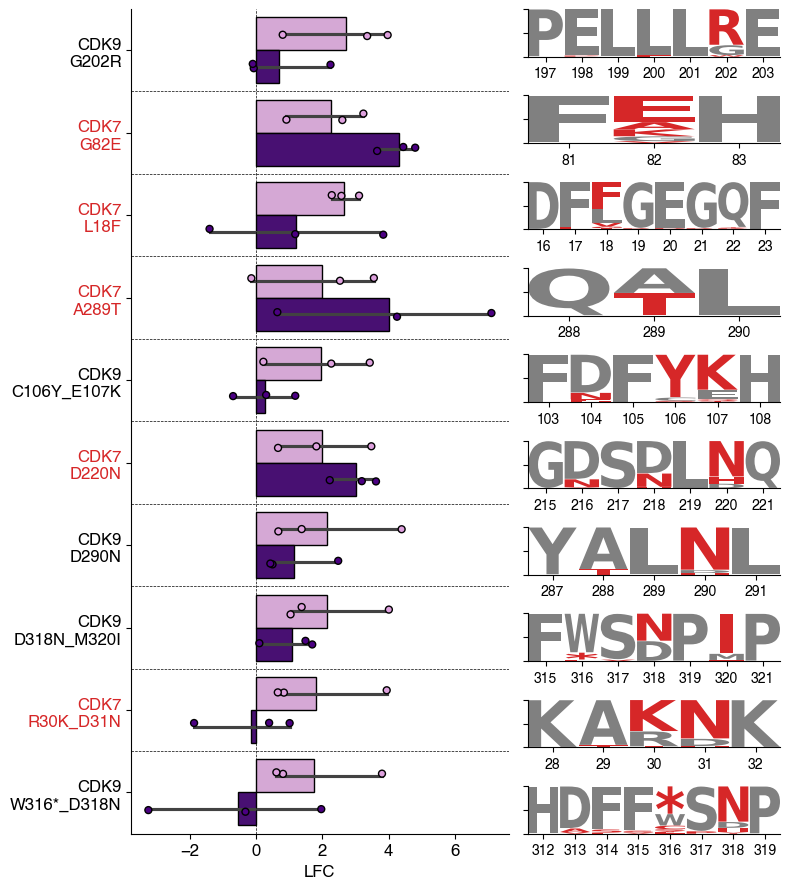

In [93]:
from matplotlib import gridspec


fig = plt.figure(figsize=(8, 9))

num_to_plot = 10
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['darkolivegreen','tab:green', 'lightgreen']
palette = ['lightcyan', 'cyan']
palette = ['plum', 'indigo']
hue_order = ['KB-0742 2 $\mu$M', 'KB-0742 4 $\mu$M']

color_dict = {'CDK7':'tab:red', 
              'CDK8':'tab:blue', 
              'CDK19':'cornflowerblue', 
              'CDK9':'black', 
              'CDK12':'tab:green', 
              'CDK13':'darkolivegreen',
              'CDK2':'goldenrod',
              'CDK4':'tab:red', 
              'CDK6':'tab:orange',}


sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
g_list = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE1[(ABE1['gRNA_id']==gRNA_id) & (ABE1['HGVSp']!='WT') & (ABE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')
        #top_hg.append(f'{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE1
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 2

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE1[(CBE1['gRNA_id']==gRNA_id) & (CBE1['HGVSp']!='WT') & (CBE1['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')
        g_list.append(g)
        #top_hg.append(f'{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    tick_label.set_color(color_dict[g_list[i]])
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower right', fontsize=10)
ax0.get_legend().remove()
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()
#fig.savefig('../../figures/compound_mut_screen_top_hits_proto_counts.pdf', transparent=True)

# Subpool 3

In [225]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_CBE_barcode_DMSO_base.csv')

condition = 'ATIRMO'
condition_a = condition

FDR_cutoff = 0.01
base_min = 100
max_WT = 90

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

WT_ABE = SAV_ABE3[SAV_ABE3['HGVSp']=='WT'].reset_index(drop=True)
WT_CBE = SAV_CBE3[SAV_CBE3['HGVSp']=='WT'].reset_index(drop=True)
WT_ABE = WT_ABE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})
WT_CBE = WT_CBE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})

data_ABE = pd.merge(data_ABE, WT_ABE, on='gRNA_id')
data_CBE = pd.merge(data_CBE, WT_CBE, on='gRNA_id')

data = pd.concat((data_ABE, data_CBE))

all_conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']

subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data['classification']=='targeting') & (data['base_RAW']>=base_min) & (data['WT_perc']<=90)].sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [284]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_CBE_barcode_DMSO_base.csv')

condition = 'ATIRMO'
condition_a = condition

FDR_cutoff = 0.01
base_min = 100
max_WT = 90

#data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
#data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

WT_ABE = SAV_ABE3[SAV_ABE3['HGVSp']=='WT'].reset_index(drop=True)
WT_CBE = SAV_CBE3[SAV_CBE3['HGVSp']=='WT'].reset_index(drop=True)
WT_ABE = WT_ABE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})
WT_CBE = WT_CBE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})

data_ABE = pd.merge(data_ABE, WT_ABE, on='gRNA_id')
data_CBE = pd.merge(data_CBE, WT_CBE, on='gRNA_id')


all_conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']
for condition in all_conditions:
    data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
    data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data = pd.concat((data_ABE, data_CBE))


s_holder = []
for condition in all_conditions:
    subset = data[(data[f'FDR_{condition}']<FDR_cutoff) & (data[f'LFC_median_{condition}']>1)& (data['classification']=='targeting') & (data['base_RAW']>=base_min) & (data['WT_perc']<=90)].sort_values(by=f'LFC_median_{condition}', ascending=False)
    s_holder.append(subset)

comb_hits = pd.concat(s_holder).drop_duplicates().reset_index(drop=True)
comb_hits['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in comb_hits.iterrows()]

In [311]:
comb_hits[comb_hits['Gene']=='CDK6'] #.sort_values(by='LFC_median_ABEMA', ascending=False)

,gRNA_id,Gene,classification,ABE_ABEMA_REP1,ABE_ABEMA_REP2,ABE_ABEMA_REP3,LFC_avg_ABE_ABEMA,LFC_median_ABEMA,base_RPM,base_RAW,...,LFC_avg_CBE_TAGTO,p_CBE_ABEMA,p_CBE_ATIRMO,p_CBE_INX,p_CBE_PALBO,p_CBE_RIBO,p_CBE_T0,FDR_CBE_T0,p_CBE_TAGTO,gRNA_id2
0,gRNA_CDK6_targ_8193,CDK6,targeting,2.503935,3.039044,1.091502,2.211494,2.503935,53.690437,196.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8193_ABE
10,gRNA_CDK6_targ_8410,CDK6,targeting,NaN,NaN,NaN,NaN,1.092805,993.340898,7507.0,...,-0.037947,0.000061,1.368904e-02,5.371618e-01,2.675981e-03,0.002415,5.898391e-01,0.952594,0.262510,gRNA_CDK6_targ_8410_CBE
15,gRNA_CDK6_targ_8215,CDK6,targeting,NaN,NaN,NaN,NaN,0.948471,851.863695,6106.0,...,0.055000,0.001169,8.982762e-06,4.694439e-01,2.422458e-04,0.001152,3.171119e-01,0.902982,0.237402,gRNA_CDK6_targ_8215_CBE
16,gRNA_CDK6_targ_8180,CDK6,targeting,2.249985,2.207383,2.350342,2.269237,2.249985,196.628973,651.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gRNA_CDK6_targ_8180_ABE
18,gRNA_CDK6_targ_8145,CDK6,targeting,NaN,NaN,NaN,NaN,0.621504,463.523800,3503.0,...,-0.097781,0.002998,3.873379e-01,1.930179e-02,3.153826e-07,0.000197,7.276563e-05,0.002331,0.422381,gRNA_CDK6_targ_8145_CBE
22,gRNA_CDK6_targ_8054,CDK6,targeting,NaN,NaN,NaN,NaN,-1.443160,28.713864,217.0,...,1.171241,0.002305,1.013276e-06,7.681109e-08,1.937209e-03,0.026979,4.131496e-07,0.000076,0.000605,gRNA_CDK6_targ_8054_CBE
23,gRNA_CDK6_targ_8102,CDK6,targeting,NaN,NaN,NaN,NaN,-0.094087,25.720482,188.0,...,-0.746675,0.066540,4.661580e-02,5.821109e-07,2.094711e-01,0.012187,2.167622e-07,0.000060,0.057982,gRNA_CDK6_targ_8102_CBE
28,gRNA_CDK6_targ_8046,CDK6,targeting,NaN,NaN,NaN,NaN,-1.788275,29.243152,221.0,...,0.592431,0.000060,3.650151e-08,1.111841e-04,2.295139e-04,0.000001,3.868060e-02,0.425034,0.039818,gRNA_CDK6_targ_8046_CBE
29,gRNA_CDK6_targ_8262,CDK6,targeting,NaN,NaN,NaN,NaN,-1.155855,69.998313,529.0,...,0.519129,0.001340,1.672267e-05,6.139867e-05,4.168515e-03,0.002313,1.187664e-02,0.144528,0.048273,gRNA_CDK6_targ_8262_CBE
30,gRNA_CDK6_targ_8264,CDK6,targeting,NaN,NaN,NaN,NaN,-0.403191,147.142011,1112.0,...,0.149999,0.105236,2.490684e-03,2.484431e-05,2.359197e-02,0.011946,5.108607e-05,0.001773,0.170445,gRNA_CDK6_targ_8264_CBE


In [305]:
#topx = subset[:20].reset_index(drop=True)
topx = comb_hits[comb_hits['Gene']=='CDK6'].sort_values(by='LFC_median_PALBO', ascending=False)
subset = topx

conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']
true_name = ['Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

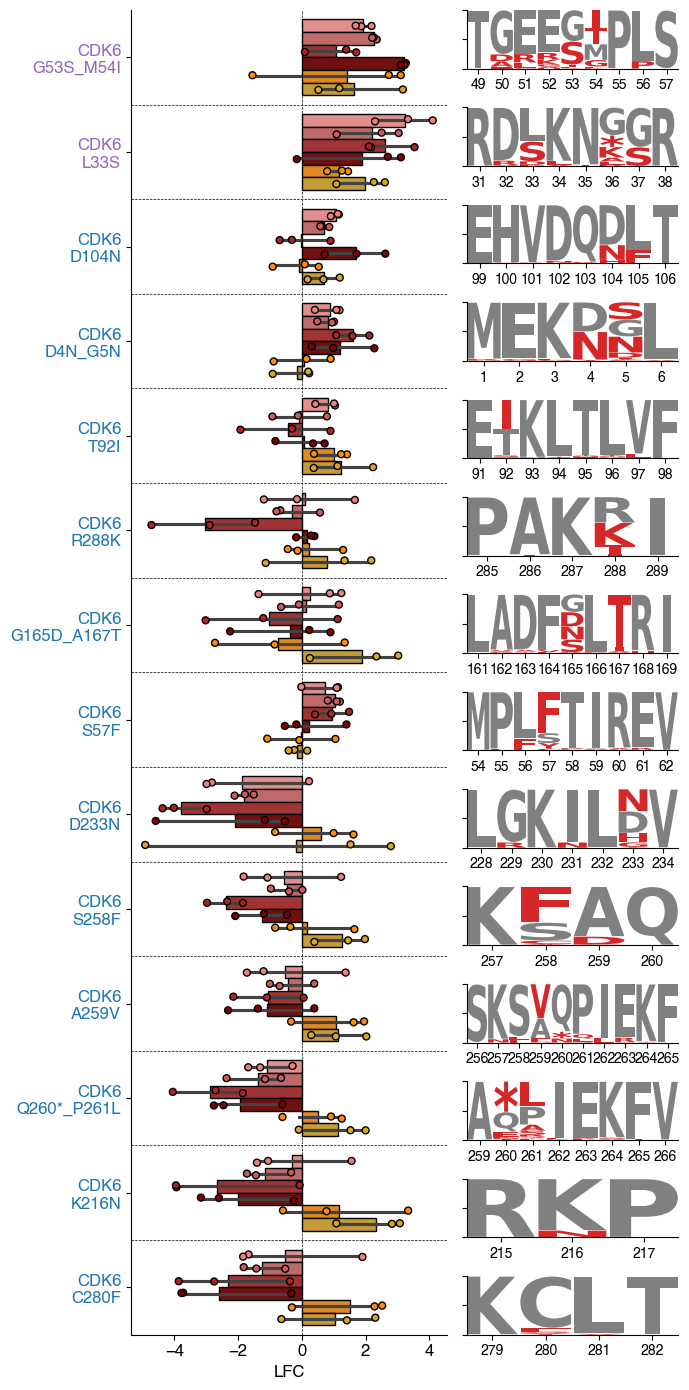

In [ ]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 14))

num_to_plot = 14
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['lightcoral', 'indianred', 'firebrick', 'maroon', 'darkorange', 'goldenrod']
hue_order = ['Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE3
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE3[(ABE3['gRNA_id']==gRNA_id) & (ABE3['HGVSp']!='WT') & (ABE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE3
        gRNA_id = val[:-4]
        #if i==3:
        #    context_size=0
        #else:
            #context_size=1
        context_size=1
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE3[(CBE3['gRNA_id']==gRNA_id) & (CBE3['HGVSp']!='WT') & (CBE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='lower left')
ax0.get_legend().remove()

ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

fig.savefig(f'../../figures/CDK6_top_vars.pdf', transparent=True)

# Subpool 3 validation set

In [621]:
CBE_guides = ['gRNA_CDK4_targ_7658',
              'gRNA_CDK2_targ_7066','gRNA_CDK2_targ_7250','gRNA_CDK2_targ_7251','gRNA_CDK2_targ_7313','gRNA_CDK2_targ_7232',
              'gRNA_CDK6_targ_8145']

ABE_guides = ['gRNA_CDK4_targ_7847','gRNA_CDK4_targ_7877','gRNA_CDK4_targ_7925','gRNA_CDK4_targ_7584',
    'gRNA_CDK6_targ_8193','gRNA_CDK6_targ_8180','gRNA_CDK6_targ_8450']

In [633]:
data_ABE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_ABE_barcode_DMSO_base.csv')
data_CBE = pd.read_csv('../../screening_data/03_LFC_FDR_tables/barcode_counts/DMSO_base/CDK2_4_6_CBE_barcode_DMSO_base.csv')

condition = 'ABEMA'
condition_a = condition

FDR_cutoff = 0.1
base_min = 100
max_WT = 90

data_ABE = data_ABE.rename(columns = {f'LFC_median_ABE_{condition}':f'LFC_median_{condition}',f'FDR_ABE_{condition}': f'FDR_{condition}'})
data_CBE = data_CBE.rename(columns = {f'LFC_median_CBE_{condition}':f'LFC_median_{condition}', f'FDR_CBE_{condition}': f'FDR_{condition}'})

data_ABE['Editor']='ABE'
data_CBE['Editor'] = 'CBE'

WT_ABE = SAV_ABE3[SAV_ABE3['HGVSp']=='WT'].reset_index(drop=True)
WT_CBE = SAV_CBE3[SAV_CBE3['HGVSp']=='WT'].reset_index(drop=True)
WT_ABE = WT_ABE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})
WT_CBE = WT_CBE[['gRNA_id', '%Reads']].rename(columns = {'%Reads':'WT_perc'})

data_ABE = pd.merge(data_ABE, WT_ABE, on='gRNA_id')
data_CBE = pd.merge(data_CBE, WT_CBE, on='gRNA_id')

data_ABE = data_ABE[data_ABE['gRNA_id'].isin(ABE_guides)]
data_CBE = data_CBE[data_CBE['gRNA_id'].isin(CBE_guides)]


data = pd.concat((data_ABE, data_CBE))

all_conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']

subset = data.sort_values(by=f'LFC_median_{condition}', ascending=False)

subset['gRNA_id2'] = [f'{val["gRNA_id"]}_{val["Editor"]}' for i, val in subset.iterrows()]

In [634]:
topx = subset[:20].reset_index(drop=True)

conditions = ['RIBO', 'ABEMA', 'ATIRMO', 'PALBO', 'TAGTO', 'INX']
true_name = ['Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315']
condition_dict = dict(zip(conditions, true_name))

condition = []
replicate = []
lfc = []
g_id = []
g_id2 = []
names = []
editor = []

for i, val in topx.iterrows():

    g = val['gRNA_id']
    #nn = val['Gene'] + ' ' + val['Top_HGVSp'] #+ f'\n({val["gRNA_id"]})'
    editor1 = val['Editor']
    

    for drug in conditions:
        d = condition_dict[drug]

        for rep in range(1,4):

            #if (f'ABE_{drug}_REP{rep}' in topx.columns) or (f'CBE_{drug}_REP{rep}' in topx.columns):
                
            if editor1=='ABE':
    
                r = f'ABE_{drug}_REP{rep}'
                l = val[r]
                
            elif editor1=='CBE':
                r = f'CBE_{drug}_REP{rep}'
                l = val[r]
       

            lfc.append(l)
            condition.append(d)
            replicate.append(rep)
            g_id.append(g)
            g_id2.append(f'{g}_{editor1}')
            editor.append(editor1)
            #names.append(nn)

plot_df = pd.DataFrame(dict(zip(['gRNA_id', 'gRNA_id2', 'Replicate', 'LFC', 'Condition', 'Editor'], [g_id, g_id2, replicate, lfc, condition, editor]))).sort_values(by='LFC', ascending=False)

In [635]:
data

,gRNA_id,Gene,classification,ABE_ABEMA_REP1,ABE_ABEMA_REP2,ABE_ABEMA_REP3,LFC_avg_ABE_ABEMA,LFC_median_ABEMA,base_RPM,base_RAW,...,p_CBE_INX,FDR_CBE_INX,p_CBE_PALBO,FDR_CBE_PALBO,p_CBE_RIBO,FDR_CBE_RIBO,p_CBE_T0,FDR_CBE_T0,p_CBE_TAGTO,FDR_CBE_TAGTO
611,gRNA_CDK4_targ_7584,CDK4,targeting,2.802662,2.352178,2.780641,2.645160,2.780641,38.027762,109.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
874,gRNA_CDK4_targ_7847,CDK4,targeting,2.967374,2.227264,2.698441,2.631026,2.698441,156.414487,394.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
904,gRNA_CDK4_targ_7877,CDK4,targeting,2.473183,2.763545,2.475260,2.570662,2.475260,258.864606,534.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
952,gRNA_CDK4_targ_7925,CDK4,targeting,1.767668,1.988534,2.294505,2.016903,1.988534,1665.773196,3725.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1207,gRNA_CDK6_targ_8180,CDK6,targeting,2.249985,2.207383,2.350342,2.269237,2.249985,196.628973,651.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1220,gRNA_CDK6_targ_8193,CDK6,targeting,2.503935,3.039044,1.091502,2.211494,2.503935,53.690437,196.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1476,gRNA_CDK6_targ_8450,CDK6,targeting,1.290051,2.093387,2.121860,1.835100,2.093387,87.933454,251.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93,gRNA_CDK2_targ_7066,CDK2,targeting,NaN,NaN,NaN,NaN,0.021850,128.219972,969.0,...,0.000141,0.008616,5.358840e-01,0.817912,3.292739e-01,0.620394,0.000047,0.001765,0.044776,0.583697
259,gRNA_CDK2_targ_7232,CDK2,targeting,NaN,NaN,NaN,NaN,0.111674,184.548093,1270.0,...,0.000747,0.028511,1.286737e-01,0.437279,2.862224e-01,0.574654,0.000971,0.017863,0.004955,0.308801
277,gRNA_CDK2_targ_7250,CDK2,targeting,NaN,NaN,NaN,NaN,-1.236181,22.523586,155.0,...,0.000178,0.009897,1.948524e-03,0.048937,1.793133e-03,0.060761,0.000096,0.002747,0.000074,0.024358


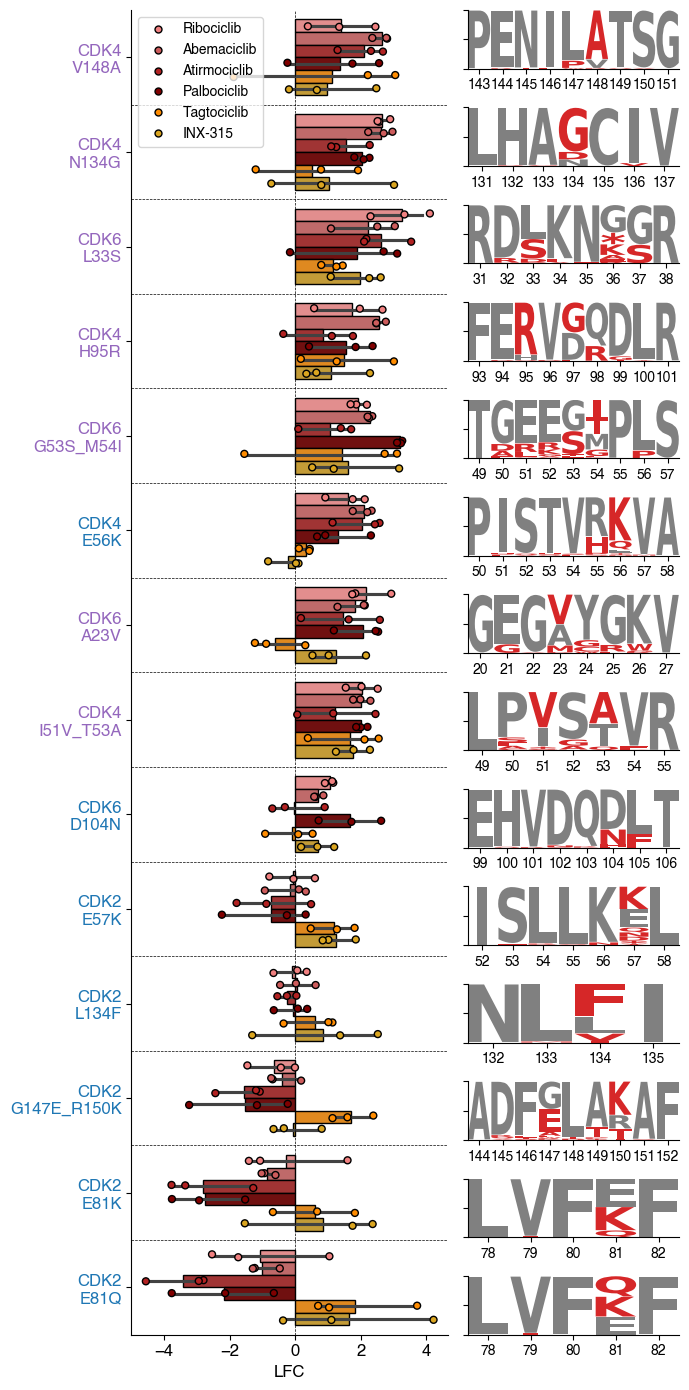

In [637]:
from matplotlib import gridspec


fig = plt.figure(figsize=(7, 14))

num_to_plot = 14
gs = gridspec.GridSpec(num_to_plot, 2, width_ratios=[1.5, 1]) 

guides = list(subset[:num_to_plot]['gRNA_id2'])
editors= list(subset[:num_to_plot]['Editor'])


ax0 = plt.subplot(gs[:,0])

palette = ['lightcoral', 'indianred', 'firebrick', 'maroon', 'darkorange', 'goldenrod']
hue_order = ['Ribociclib', 'Abemaciclib', 'Atirmociclib', 'Palbociclib', 'Tagtociclib', 'INX-315']

sns.barplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, linewidth=1, edgecolor='black', legend=False, hue_order=hue_order, palette=palette)
sns.stripplot(data=plot_df, x='LFC', hue='Condition', y='gRNA_id2', order=guides, ax=ax0, dodge=True, linewidth=1, edgecolor='black', hue_order=hue_order, palette=palette)


top_hg = []
for i, val in enumerate(guides):

    if editors[i]=='ABE':
        merge = SAV_ABE3
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = ABE3[(ABE3['gRNA_id']==gRNA_id) & (ABE3['HGVSp']!='WT') & (ABE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')

        
    elif editors[i]=='CBE':
        merge = SAV_CBE3
        gRNA_id = val[:-4]
        context_size=1
        min_perc = 1

        logo_df, min_cod, max_cod, d4, sequence = logo_df_maker(merge, gRNA_id, context_size, min_perc)

        ax1 = plt.subplot(gs[i,1])
        
        ss_logo = logomaker.Logo(logo_df, vpad = .02, ax=ax1)
        ss_logo.style_xticks(anchor=0, spacing=1, rotation=0, fontsize=10)
        ss_logo.ax.set_yticks([0,50,100])
        ss_logo.ax.set_yticklabels([], fontsize=10);
        #ss_logo.ax.set_xlabel('Amino Acid', fontsize=14)
        #ss_logo.ax.set_ylabel('Probability', fontsize=14)

        ss_logo.ax.get_xticks()

        d_nonzero = d4[d4['%Reads']>0]


        for i, val in d_nonzero.iterrows():
            alt = val['alt']
            loc = val['codon']
            pp = val['%Reads']
            ss_logo.style_single_glyph(c=alt, p=loc, color='tab:red')

        ss_logo.style_spines(spines=['right', 'top'], visible=False)

        subset2 = CBE3[(CBE3['gRNA_id']==gRNA_id) & (CBE3['HGVSp']!='WT') & (CBE3['%Reads']>=min_perc)]
        

        g = merge.loc[merge['gRNA_id']==gRNA_id, 'Gene'].values[0]
        hg = list(subset2['HGVSp'])[0]
        top_hg.append(f'{g}\n{hg}')



ax0.set_yticklabels(top_hg)

for i, tick_label in enumerate(ax0.axes.get_yticklabels()):
    if editors[i]=='ABE':
        tick_label.set_color("tab:purple")
    if editors[i]=='CBE':
        tick_label.set_color("tab:blue")
        
ax0.tick_params(axis='both', which='major', labelsize=12)
ax0.set_ylabel('')
ax0.set_xlabel('LFC', fontsize=12)

for i in range(num_to_plot-1):
    ax0.axhline(i+0.5, linestyle='dashed', color='black', linewidth=0.5)


ax0.legend(loc='upper left')
ax0.axvline(0, linestyle='dashed', color='black', linewidth=0.5)
ax0.spines[['right', 'top']].set_visible(False)
fig.tight_layout()

#fig.savefig(f'../../figures/{condition_a}_validation_guides_sub3.pdf', transparent=True)

# version with DNA? too much?

In [182]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(4, 2, width_ratios=[3, 1]) 
gs[0]

GridSpec(4, 2, width_ratios=[3, 1])[0:1, 0:1]

<Figure size 1200x600 with 0 Axes>